# Clustering configs

## functions

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import matplotlib.patches as mpatches
import os
import json
import pandas as pd

def get_cluster_files (cluster, df_path):
    df_assignments = pd.read_csv(df_path)
    df_assignments_filtered =  df_assignments[ df_assignments["label"].str.contains(str(cluster))]
    cluster_files = df_assignments_filtered ["file"].values
    cluster_genres = [genres for genres in df_assignments_filtered ["label"].unique() if "(" in genres ][0]
    return cluster_files, cluster_genres

def get_restults_per_cluster (json_path,  cluster, seeds, df_path, full= False,cluster_config = None, per_cluster = False, name = None, return_per_track = False, all_metrics = False ):
    if full:
        folder = os.path.join(json_path, "full_data", name) #  "full_data"
    elif all_metrics:
        folder_metrics = os.path.join(json_path,"all_data_metrics")
        cluster_config_folder = cluster_config if cluster_config is not None else ""
        folder = os.path.join(folder_metrics, cluster_config_folder, name)
        
    else:
        #cluster_config = f"clusters{n_clusters}_layer{layer}"
        folder =  os.path.join(json_path, cluster_config, f"{cluster}", name)
    
    cluster_files, cluster_genres = get_cluster_files (cluster= cluster, df_path = df_path)
    # if (per_cluster and  full) or (not full):
       
    cluster_files = [file.replace("___", "/") for file in cluster_files]
    #print(cluster_files)
    scores = []
    for seed in seeds:
        file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]
        json_file = open(os.path.join(folder, file_scores))
        
        json1_str = json_file.read()
        json1_data = json.loads(json1_str)
        json_data = {key[:-10]: value for key, value in json1_data.items()} #{key[:-10]: value for key, value in json1_data.items()}
        df  = pd.DataFrame(json_data).T
        #print(len(df))
        #print(json_data)
        if full and per_cluster:
            ind = set(df.index)
            cl = set(cluster_files)
            #print(cl)
            val_files_cluster = ind & cl
            df_val_cluster = df.loc[list(val_files_cluster)]
            df_val_cluster.index = df_val_cluster.index.astype(str) + "/track.npy"
            #print(df_val_cluster.head(10))
            #print(len(df_val_cluster))
        else:
            df_val_cluster = df.copy()
        if seed == 0:
            print(f"using file   {os.path.join(folder, file_scores)}")
            print(f"number of files {df_val_cluster.shape}")
        if return_per_track:
            return df_val_cluster
        df_percents = df_val_cluster*100

        scores_mean = (df_percents .mean()).to_dict()
        scores.append(scores_mean)

    if not full:
        genres = cluster_genres[cluster_genres.find("(")+1:cluster_genres.find(")")]
        print(f"genres are {genres}")
        return scores, genres
    return scores

In [2]:
import os
import json
import pandas as pd
import pandas as pd

def mean_scores(scores_list):
    """
    scores_list: List[Dict[str, float]]
    returns: Dict[str, float] with mean values
    """
    return pd.DataFrame(scores_list).mean().to_dict()
def std_scores(scores_list):
    """
    scores_list: List[Dict[str, float]]
    returns: Dict[str, float] with mean values
    """
    return pd.DataFrame(scores_list).std().to_dict()

def extract_mean_std(scores, extract_std = False, trial= None, decimals = 3):
    suffix = "baseline" if trial is None else f"trial_{trial}"
    mean_dict = mean_scores(scores)
    if not extract_std:
        res = pd.DataFrame.from_dict(
            mean_dict,
            orient="index",
            columns=[suffix]
        ).T
    else:
        std_dict = std_scores(scores)

        # format as "95.2 +- 0.2"
        fmt = f"{{:.{decimals}f}}"
        combined = {
            k: f"{fmt.format(mean_dict[k])} +- {fmt.format(std_dict[k])}"
            for k in mean_dict.keys()
        }

        res = pd.DataFrame.from_dict(
            combined,
            orient="index",
            columns=[suffix]
        ).T
    return res

def remove_cemgil (df):
    wt_cemgil= [col for col in df.columns.values if "Cemgil" not in col]
    df= df[wt_cemgil]
    return df

def get_per_cluster_results(trials, seeds,json_path, cluster, name_full, cluster_config = None, 
                 df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv", trial_names = None, extrat_std = False, decimals = 3):
    df_list = []
    for trial in trials:
        name = trial_names.get(trial, "") if trial_names else ""
        scores, genres = get_restults_per_cluster(
                    json_path, cluster=cluster, seeds=seeds, cluster_config=cluster_config,
                    df_path=df_path, full=False, per_cluster=True, name = f"cluster_{cluster}_trial_{trial}{name}"
                
                )
        if len(seeds) >1:
            res = extract_mean_std(scores, trial = trial, extract_std=extrat_std, decimals = decimals)
         
        else:
            res = pd.DataFrame.from_dict(scores[0]  , orient="index", columns=[f"trial_{trial}"])
            res = pd.DataFrame(res).T 
        # res = pd.DataFrame.from_dict(scores_cl2[0]  , orient="index", columns=[f"trial_{trial}"])
        # res = pd.DataFrame(res).T 
        
        
        df_list.append(res)

    scores_base = get_restults_per_cluster(
                json_path, cluster=cluster, seeds=seeds, cluster_config=cluster_config,
                df_path=df_path, full=True, per_cluster=True, name = name_full
            )
    
    
    if len(seeds) >1:
        res_base = extract_mean_std(scores_base, trial = None, extract_std=extrat_std, decimals = decimals)
    else:
        res_base = pd.DataFrame.from_dict(scores_base[0]  , orient="index", columns=[f"baseline"])
        res_base = pd.DataFrame(res_base).T
    df_list.append(res_base)
    df_total = pd.concat(df_list, axis=0)
    df_total = remove_cemgil(df_total)
    # wt_cemgil= [col for col in df_total.columns.values if "Cemgil" not in col]
    # df_total= df_total[wt_cemgil]
    return df_total 


def get_baseliine_diff(df_total, num_trials):
    df_baseline = df_total.loc["baseline"]
    diff_vs_baseline = df_total[:num_trials].subtract(df_total.loc["baseline"])
    diff_vs_baseline
    diff_vs_baseline = pd.concat([diff_vs_baseline, df_baseline.to_frame().T], axis=0)
    return diff_vs_baseline


def get_latex_row(df, remove_cemgil = True):
    if remove_cemgil:
        wt_cemgil= [col for col in df.columns.values if "Cemgil" not in col]
        df= df[wt_cemgil]
    rows = [
    " & ".join(f"{x:.3f}" if isinstance(x, (int, float)) else str(x) for x in row)
    for row in df.values
]
    return rows

In [3]:
import re
import numpy as np
def _extract_mean(value):
    """Extract numeric mean from strings like '96.643 +- 0.114', '96.643 ± 0.114', '96.643 \\pm 0.114'."""
    s = str(value)
    # strip math and whitespace
    s = s.replace("$", "").strip()
    # normalise all kinds of +- / ± / \pm to '+-'
    s = s.replace(r"\pm", "+-").replace("±", "+-")
    if "+-" in s:
        mean_part = s.split("+-")[0].strip()
    else:
        # fall back: first token
        mean_part = s.split()[0].strip()
    try:
        return float(mean_part)
    except ValueError:
        return np.nandf_total

In [4]:
def df_to_latex_rows(
    df,
    rename_idx=None,
    bold_index=True,
    pm=False,
    bold_difference=False,
    bold_baseline_if_best=False
):
    rows = []

    # ---------- locate baseline ----------
    baseline_idx = None
    for idx in df.index:
        if "baseline" in str(idx).lower():
            baseline_idx = idx
            break

    baseline_means = {}
    if baseline_idx is not None:
        for col in df.columns:
            baseline_means[col] = _extract_mean(df.loc[baseline_idx, col])

    # ---------- if we bold baseline when best, precompute ----------
    baseline_best_cols = set()
    if bold_baseline_if_best and baseline_idx is not None:
        for col in df.columns:
            others = [
                _extract_mean(df.loc[i, col])
                for i in df.index
                if i != baseline_idx
            ]
            if len(others) > 0:
                if baseline_means[col] >= np.nanmax(others):
                    baseline_best_cols.add(col)

    # ---------- build rows ----------
    for i, (idx, row) in enumerate(df.iterrows()):
        label = str(rename_idx[i]) if rename_idx is not None else str(idx)
        if bold_index:
            label = rf"\textbf{{{label}}}"

        is_baseline_row = "baseline" in str(idx).lower()
        cell_strs = []

        for col, v in row.items():
            s = str(v)
            s = s.replace("+-", r"\pm")
            if pm:
                s = s.replace("±", r"\pm")
            else:
                s = s.replace("±", r"\pm")

            # -------- bold logic --------
            bold_mean_here = False

            if bold_difference and not is_baseline_row and col in baseline_means:
                mean_val = _extract_mean(v)
                base_val = baseline_means[col]
                if not np.isnan(mean_val) and mean_val > base_val:
                    bold_mean_here = True

            if bold_baseline_if_best and is_baseline_row and col in baseline_best_cols:
                bold_mean_here = True

            if bold_mean_here:
                pm_pos = s.find(r"\pm")
                if pm_pos != -1:
                    mean_part = s[:pm_pos].strip()
                    rest = s[pm_pos:].lstrip()
                    s = rf"\mathbf{{{mean_part}}} {rest}"
                else:
                    s = rf"\mathbf{{{s}}}"

            cell_strs.append(f"${s}$")

        row_str = " & ".join([label] + cell_strs) + r" \\"
        rows.append(row_str)

    return rows

In [5]:
def df_to_latex_rows(df, rename_idx=None, bold_index = True, pm = False, bold_difference = False):
    """
    rename_idx: list of new names in the SAME order as df rows
                e.g., ["Cluster Model", "Baseline"]
    """
    rows = []
    
    for i, (idx, row) in enumerate(df.iterrows()):
        label = str(rename_idx[i]) if rename_idx is not None else str(df.index[i])
        
        if bold_index:
            label = rf"\textbf{{{label}}}"
        # choose label from list if provided
        # if rename_idx is not None:
        #     label = str(rename_idx[i])
        # else:
        #     label = str(idx)
        
        vals = [str(v).replace("+-", r"\pm") for v in row]
        if pm:
            vals = [str(v).replace("±", r"\pm") for v in row]
        vals = [f"${v}$" for v in vals]

        row_str = " & ".join([label] + vals) + r" \\"
        rows.append(row_str)

    return rows

In [6]:
import pandas as pd
import os
import json
import numpy as np
# create df of results for the baseline model trained on the 
# full data with a corresponding seed
def construct_df_full_data (json_path,  seed, rename_columns = None, names = None, best = True):
    if names:
        name = names[0]
        subfolder = "full_data"
    else:
        name = ""
        subfolder = "full_data_intermediate_checkpoints"
    folder = os.path.join(json_path, subfolder, name)  # 
    print(folder)
    prefix = f"best-seed{seed}" if best else f"seed_{seed}"
    file_scores = [file for file in os.listdir(folder) if prefix in file][0]
    #print(file_scores)
    json_file = open(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    #print(len(clsuter_keys))
    df  = pd.DataFrame(json1_data).T
    if rename_columns is not None:
       mapping = { col: f"{col}_{rename_columns}_{seed}" for col in df.columns}
       df = df.rename(columns=mapping)
    return df

# cerate df of results for the clustering configutation for one cluster
def construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number,rename_columns= None, names = None):
    if names:
        name = names[cluster_number]
    else:
        name = ""
    folder = os.path.join(json_path, cluster_config, f"{cluster_number}", name)
    # if seed == 0:
    #     print(folder)
    file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]   # f"best_checkpoint-seed{seed}" in file best_checkpoint-seed

    json_file = open(os.path.join(folder, file_scores))
    if seed == 0:
        print(file_scores)
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    #print(len(clsuter_keys))
    df  = pd.DataFrame(json1_data).T
    if rename_columns is not None:
       mapping = { col: f"{col}_{rename_columns}_{seed}" for col in df.columns}
       df = df.rename(columns=mapping)
    return df

# join results for all clusters in the given clustering configuration and join then in final df
def construct_total_df (json_path, seed, cluster_config, cluster_numbers, rename_columns= None, names = None, skip_cluster = [], df_path = None):
    df_list = []
    #print(skip_cluster)
    for cluster_number in cluster_numbers:
        if cluster_number in skip_cluster:
            print(f"skipping cluster {cluster_number}")
            df_cluster  = get_restults_per_cluster(
                json_path, cluster=cluster_number, seeds=[seed], cluster_config=cluster_config,
                df_path=df_path, full=True, per_cluster=True, name = names[0], return_per_track=True
            )
            col_down = [col for col in df_cluster.columns.values if "F-measure_downbeat" in col][0]
            #print(f"total sum for cluster {cluster_number} skipped is {df_cluster[col_down].sum()}")
            # res_base = pd.DataFrame.from_dict(scores_cl_base[0]  , orient="index", columns=[f"baseline"])
            # df_cluster = pd.DataFrame(res_base)
            
            
        else:
            
            df_cluster = construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number, rename_columns= rename_columns, names = names)
            col_down = [col for col in df_cluster.columns.values if "F-measure_downbeat" in col][0]
           # print(f"total sum for cluster {cluster_number} is {df_cluster[col_down].sum()}")
        #print(f"cluster len is {len(df_cluster)}")
        if seed == 0:
            print(df_cluster.shape)
        df_list.append (df_cluster)
    df_total = pd.concat(df_list, axis=0)
    df = df_total.groupby(df_total.index).mean()
    # sanity check on number of validation files (should be 556)
    #assert len(df) == 556
    #print(f"Final size of df is {len(df)}")
    return df

# get dict of differences between the baseline model and configuration model
# returns dict with keys that are beat tracking metrics
def get_performance_differences(df_total, df_full):
    means_total = (df_total.mean()* 100).to_dict()
    means_full =(df_full.mean()*  100).to_dict()
    diff_dict = {list(means_total.keys())[i]: means_total[list(means_total.keys())[i]] - means_full[list(means_full.keys())[i]] for i in range(len(means_full))}
    return diff_dict

# utility function to rename dictionary keys
def rename_keys_dict(d):
    dict_new = {}
    for key in d.keys():
        new_key = "_".join(key.split("_")[:-1])
        dict_new [new_key] = d[key]
    return dict_new

# get differences in performance for a particular configuration for all seeds
def get_total_results (seeds, json_val_path,layer, clusters, ):
    df_list = []
    cluster_numbers = np.arange(clusters) +1
    cluster_config = f"clusters{clusters}_layer{layer}"
    for seed in seeds:
        df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers)
        df_full = construct_df_full_data (json_val_path, seed=seed, rename_columns="baseline")
        diff_dict = get_performance_differences (df_total, df_full)
        diff_dict_renamed = rename_keys_dict(diff_dict)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(diff_dict_renamed, orient="index", columns=[f"Value_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    return df_result

In [7]:
def get_total_results_new(seeds, json_val_path,layer = None, clusters = None, full = False, rename_columns = None, names = None, skip_cluster = [], df_path = None, decimals = 2, best = True):
    df_list = []
    for seed in seeds:
        if full:
            df_total = construct_df_full_data (json_val_path, seed=seed, rename_columns=rename_columns, names = names, best= best)
            col_down = [col for col in df_total.columns.values if "F-measure_downbeat" in col][0]
            sum_full = df_total[col_down].sum() 
            #print(f"total sum is {sum_full}")   
            if seed == 0:
                print(len(df_total))
        else:
            cluster_numbers = np.arange(clusters) +1
            cluster_config = f"clusters{clusters}_layer{layer}"
            df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers, 
                                           rename_columns=rename_columns, names = names, skip_cluster = skip_cluster, df_path = df_path)
            #print(f"the total cluster dif is {len(df_total)}")
        means_total = (df_total.mean()* 100).to_dict()
        means_total_renamed =means_total.copy()# rename_keys_dict(means_total)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(means_total_renamed  , orient="index", columns=[f"configuration_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    df_seeds_mean = df_result.mean(axis = 1)
    df_seeds_std = df_result.std(axis = 1)
    df_final = df_seeds_mean.round(decimals).astype(str) + " ± " + df_seeds_std.round(decimals).astype(str)
    return df_seeds_mean, df_seeds_std, df_final

## results

In [8]:
seeds = [0,1,2]
json_val_path =  "json_val_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_val_path , full = True ) #rename_columns="baseline"
# df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results_new(seeds = seeds, json_val_path = json_val_path , layer = 6, clusters = 2)
# df_seeds_mean, df_seeds_std, df_final_clusters4_layer12 = get_total_results_new(seeds = seeds, json_val_path = json_val_path , layer = 12, clusters = 4)
# df_seeds_mean, df_seeds_std, df_final_clusters3_layer113= get_total_results_new(seeds =seeds , json_val_path = json_val_path , layer = 113, clusters = 3)
configs = {
    # "clusters2_layer6": df_final_clusters2_layer6,
    # "clusters4_layer12": df_final_clusters4_layer12,
    
    # "clusters3_raw" : df_final_clusters3_layer113,
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
#final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df

556


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
baseline,92.66 ± 0.43,84.81 ± 0.36,84.89 ± 0.83,88.7 ± 0.45,85.14 ± 0.41,79.02 ± 0.41,72.47 ± 0.43,80.0 ± 0.72


In [47]:
seeds = [0,1,2]
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = "json_val_scores", full = True ) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results_new(seeds = seeds, json_val_path = "json_val_scores", layer = 6, clusters = 2)
df_seeds_mean, df_seeds_std, df_final_clusters4_layer12 = get_total_results_new(seeds = seeds, json_val_path = "json_val_scores", layer = 12, clusters = 4)
df_seeds_mean, df_seeds_std, df_final_clusters3_layer113= get_total_results_new(seeds =seeds , json_val_path = "json_val_scores", layer = 113, clusters = 3)
configs = {
    "clusters2_layer6": df_final_clusters2_layer6,
    "clusters4_layer12": df_final_clusters4_layer12,
    
    "clusters3_raw" : df_final_clusters3_layer113,
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
#final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df

best-seed0-epoch=78-valfval_F-measure_beat=0.9395.json
556
best-seed1-epoch=87-valfval_F_measure_beat=0.0000.json
best-seed2-epoch=75-valfval_F-measure_beat=0.9355.json
best-seed0-epoch=12-valfval_F-measure_beat=0.9718_orig.json
best-seed0-epoch=28-valfval_F-measure_beat=0.8925_orig.json
best-seed0-epoch=02-valfval_F-measure_beat=0.9753_orig.json
best-seed0-epoch=17-valfval_F-measure_beat=0.9572_orig.json
best-seed0-epoch=00-valfval_F-measure_beat=0.9718_orig.json
best-seed0-epoch=70-valfval_F-measure_beat=0.8321_orig.json
best-seed0-epoch=01-valfval_F-measure_beat=0.8828_orig.json
best-seed0-epoch=20-valfval_F-measure_beat=0.9711_orig.json
best-seed0-epoch=01-valfval_F-measure_beat=0.9660_orig.json


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters2_layer6,92.842 ± 0.32,84.851 ± 0.294,85.247 ± 0.356,88.88 ± 0.519,85.267 ± 0.395,79.101 ± 0.451,72.801 ± 0.299,80.468 ± 0.827
clusters4_layer12,92.793 ± 0.267,84.882 ± 0.276,85.208 ± 0.342,88.857 ± 0.584,85.279 ± 0.37,79.087 ± 0.352,72.797 ± 0.044,80.254 ± 0.101
clusters3_raw,92.737 ± 0.266,84.77 ± 0.244,85.092 ± 0.441,88.724 ± 0.293,85.107 ± 0.404,78.946 ± 0.372,72.604 ± 0.097,80.091 ± 0.331
baseline,92.655 ± 0.432,84.806 ± 0.357,84.891 ± 0.828,88.703 ± 0.448,85.143 ± 0.41,79.019 ± 0.405,72.473 ± 0.427,79.997 ± 0.715


In [ ]:
seeds = [0,1,2]
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = "json_val_scores", full = True ) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results(seeds = seeds, json_val_path = "json_val_scores", layer = 6, clusters = 2)
df_seeds_mean, df_seeds_std, df_final_clusters4_layer12 = get_total_results(seeds = seeds, json_val_path = "json_val_scores", layer = 12, clusters = 4)
df_seeds_mean, df_seeds_std, df_final_clusters3_layer113= get_total_results(seeds =seeds , json_val_path = "json_val_scores", layer = 113, clusters = 3)
configs = {
    "clusters2_layer6": df_final_clusters2_layer6,
    "clusters4_layer12": df_final_clusters4_layer12,
    
    "clusters3_raw" : df_final_clusters3_layer113,
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
#final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters2_layer6,92.842 ± 0.32,84.851 ± 0.294,85.247 ± 0.356,88.88 ± 0.519,85.267 ± 0.395,79.101 ± 0.451,72.801 ± 0.299,80.468 ± 0.827
clusters4_layer12,92.793 ± 0.267,84.882 ± 0.276,85.208 ± 0.342,88.857 ± 0.584,85.279 ± 0.37,79.087 ± 0.352,72.797 ± 0.044,80.254 ± 0.101
clusters3_raw,92.737 ± 0.266,84.77 ± 0.244,85.092 ± 0.441,88.724 ± 0.293,85.107 ± 0.404,78.946 ± 0.372,72.604 ± 0.097,80.091 ± 0.331
baseline,92.655 ± 0.432,84.806 ± 0.357,84.891 ± 0.828,88.703 ± 0.448,85.143 ± 0.41,79.019 ± 0.405,72.473 ± 0.427,79.997 ± 0.715


In [185]:
def extract_mean(series):
    return series.str.split("±").str[0].astype(float)
df_means_only = final_df.apply(extract_mean, axis=1)
diff_vs_baseline = df_means_only.subtract(df_means_only.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters6_layer12,0.07,-0.01,0.15,0.21,0.08,-0.03,0.25,0.25


In [12]:
df_seeds_mean, df_seeds_std, df_final = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", full = True ) #rename_columns="baseline"
df_final

F-measure_beat        92.655 ± 0.432
Cemgil_beat           84.806 ± 0.357
CMLt_beat             84.891 ± 0.828
AMLt_beat             88.703 ± 0.448
F-measure_downbeat     85.143 ± 0.41
Cemgil_downbeat       79.019 ± 0.405
CMLt_downbeat         72.473 ± 0.427
AMLt_downbeat         79.997 ± 0.715
dtype: object

In [78]:
df_seeds_mean, df_seeds_std, df_final = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
df_final

F-measure_beat         92.842 ± 0.32
Cemgil_beat           84.851 ± 0.294
CMLt_beat             85.247 ± 0.356
AMLt_beat              88.88 ± 0.519
F-measure_downbeat    85.267 ± 0.395
Cemgil_downbeat       79.101 ± 0.451
CMLt_downbeat         72.801 ± 0.299
AMLt_downbeat         80.468 ± 0.827
dtype: object

In [79]:
df_seeds_mean, df_seeds_std, df_final= get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 12, clusters = 4)
df_final

F-measure_beat        92.793 ± 0.267
Cemgil_beat           84.882 ± 0.276
CMLt_beat             85.208 ± 0.342
AMLt_beat             88.857 ± 0.584
F-measure_downbeat     85.279 ± 0.37
Cemgil_downbeat       79.087 ± 0.352
CMLt_downbeat         72.797 ± 0.044
AMLt_downbeat         80.254 ± 0.101
dtype: object

In [80]:
df_seeds_mean, df_seeds_std, df_final= get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 113, clusters = 3)
df_final

F-measure_beat        92.737 ± 0.266
Cemgil_beat            84.77 ± 0.244
CMLt_beat             85.092 ± 0.441
AMLt_beat             88.724 ± 0.293
F-measure_downbeat    85.107 ± 0.404
Cemgil_downbeat       78.946 ± 0.372
CMLt_downbeat         72.604 ± 0.097
AMLt_downbeat         80.091 ± 0.331
dtype: object

In [28]:
df2 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
df2

,Value_0,Value_1,Value_2
F-measure_beat_clusters2_layer6,0.194616,0.070607,0.294833
Cemgil_beat_clusters2_layer6,0.211529,-0.197048,0.118469
CMLt_beat_clusters2_layer6,0.604886,-0.204598,0.667013
AMLt_beat_clusters2_layer6,0.648409,-0.203882,0.084351
F-measure_downbeat_clusters2_layer6,0.323536,-0.018012,0.065326
Cemgil_downbeat_clusters2_layer6,0.355536,-0.125521,0.015311
CMLt_downbeat_clusters2_layer6,0.673556,0.173159,0.138442
AMLt_downbeat_clusters2_layer6,1.391031,0.252737,-0.229233


In [ ]:
# using df with per track cluster assignments, return only tracks
# that belong to the chosen cluster
def get_cluster_files (cluster, df_path):
    df_assignments = pd.read_csv(df_path)
    df_assignments_filtered =  df_assignments[ df_assignments["label"].str.contains(str(cluster))]
    cluster_files = df_assignments_filtered ["file"].values
    cluster_genres = [genres for genres in df_assignments_filtered ["label"].unique() if "(" in genres ][0]
    return cluster_files, cluster_genres

#compute scores only for tracks from a given cluster
# when per_cluster set to False, we compute scores for all tracks
def old_get_restults_per_cluster (json_path,  cluster, seeds, df_path, full= False, layer = None, n_clusters = None, per_cluster = True ):
    if full:
        folder = os.path.join(json_path, "full_data")
    else:
        cluster_config = f"clusters{n_clusters}_layer{layer}"
        folder =  os.path.join(json_path, cluster_config, f"{cluster}")
    cluster_files, cluster_genres = get_cluster_files (cluster= cluster, df_path = df_path)
    print(f"genres are {cluster_genres}")
    cluster_files = [file.replace("___", "/") for file in cluster_files]
    #print(cluster_files)
    scores = []
    for seed in seeds:
        file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]
        json_file = open(os.path.join(folder, file_scores))
        json1_str = json_file.read()
        json1_data = json.loads(json1_str)
        json_data =json1_data.copy() #{key[:-10]: value for key, value in json1_data.items()}  # !!!!!!!
        df  = pd.DataFrame(json_data).T
        if full and per_cluster:
            ind = set(df.index)
            cl = set(cluster_files)
            val_files_cluster = ind & cl
            df_val_cluster = df.loc[list(val_files_cluster)]
        else:
            df_val_cluster = df.copy()
        scores_mean = (df_val_cluster.mean()*100).to_dict()
        scores.append(scores_mean)
    print(len(df_val_cluster))
    return scores

In [24]:
df2 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
clusters2_layer6 = df2.mean(axis = 1).to_dict()
clusters2_layer6 = {key.split("_clusters")[0]: value for key, value in clusters2_layer6.items()}
clusters2_layer6 
#df2
df_res2 = pd.DataFrame.from_dict(clusters2_layer6 , orient="index", columns=[f"Value_{1}"])
df_res2

,Value_1
F-measure_beat,0.186685
Cemgil_beat,0.044317
CMLt_beat,0.355767
AMLt_beat,0.176293
F-measure_downbeat,0.123617
Cemgil_downbeat,0.081775
CMLt_downbeat,0.328386
AMLt_downbeat,0.471512


In [25]:
df4 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 12, clusters = 4)
df4.mean(axis = 1)


F-measure_beat_clusters4_layer12        0.138007
Cemgil_beat_clusters4_layer12           0.076018
CMLt_beat_clusters4_layer12             0.316776
AMLt_beat_clusters4_layer12             0.153491
F-measure_downbeat_clusters4_layer12    0.135693
Cemgil_downbeat_clusters4_layer12       0.068235
CMLt_downbeat_clusters4_layer12         0.323590
AMLt_downbeat_clusters4_layer12         0.257154
dtype: float64

In [83]:
df3 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 113, clusters = 3)
df3.mean(axis = 1)


F-measure   -0.036221
Cemgil      -0.072493
CMLt         0.130712
AMLt         0.093984
dtype: float64

In [8]:
df2 = get_total_results(seeds = [0,1,2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
df2.mean(axis = 1)


F-measure    0.123617
Cemgil       0.081775
CMLt         0.328386
AMLt         0.471512
dtype: float64

In [27]:

json_path = "json_val_scores"
scores = get_restults_per_cluster (json_path,  cluster = 4, seeds = [0,1,2], df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", full = True, per_cluster=False )
df = pd.DataFrame(scores)

summary = pd.DataFrame({
    "mean": df.mean(),
    "std": df.std()
})
summary

genres are 4 (Classical)
556


,mean,std
F-measure_beat,92.655061,0.431561
Cemgil_beat,84.806237,0.357194
CMLt_beat,84.891240,0.828499
AMLt_beat,88.703282,0.447577
F-measure_downbeat,85.142924,0.409585
Cemgil_downbeat,79.018963,0.405184
CMLt_downbeat,72.473105,0.427301
AMLt_downbeat,79.996665,0.715134


In [11]:
json_path = "json_val_scores"
layer = 12
cluster_numbers = [1,2,3,4]
df_list = []
seed = 0
cluster_config = "clusters4_layer12"
for cluster_number in cluster_numbers:
    df_cluster = construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number, rename_columns= cluster_config)
    df_list.append (df_cluster)
df_total = pd.concat(df_list, axis=0)
df = df_total.groupby(df_total.index).mean()
# sanity check on number of validation files (should be 556)
print(f"Final size of df is {len(df)}")
df.head()

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556


,F-measure_beat_clusters4_layer12_0,Cemgil_beat_clusters4_layer12_0,CMLt_beat_clusters4_layer12_0,AMLt_beat_clusters4_layer12_0,F-measure_downbeat_clusters4_layer12_0,Cemgil_downbeat_clusters4_layer12_0,CMLt_downbeat_clusters4_layer12_0,AMLt_downbeat_clusters4_layer12_0
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,0.979206,0.932761,0.929104,0.929104,0.653061,0.668686,0.131783,0.458647
asap/Bach_Fugue_bwv_874_BianF01/track.npy,0.106383,0.086865,0.000000,0.580311,0.070000,0.047430,0.000000,0.000000
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,0.664384,0.751126,0.000000,0.979487,0.574850,0.647456,0.000000,0.621849
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,0.664384,0.764902,0.000000,0.974359,0.540230,0.618602,0.000000,0.515873
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,0.733333,0.706838,0.401460,0.401460,0.380952,0.402207,0.000000,0.240506


In [ ]:
cluster_files, cluster_genres = get_cluster_files (cluster= 1, config="clusters4_layer12" )
len(cluster_files)
cluster_files = [file.replace("___", "/") for file in cluster_files]
cluster_files

In [66]:
json_path = "json_val_scores"
seed = 0
folder = os.path.join(json_path, "full_data")
file_scores = [file for file in os.listdir(folder) if f"best-seed{seed}" in file][0]

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
json_data = {key[:-10]: value for key, value in json1_data.items()}
clsuter_keys = set(json_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json_data).T
ind = set(df.index)
cl = set(cluster_files)
val_files_cluster = ind & cl
df_val_cluster = df.loc[list(val_files_cluster)]
df_val_cluster.head()

556


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
ballroom/ballroom_Albums-Mambo_Kings-12,1.000000,0.974577,1.000000,1.000000,1.000000,0.980364,1.000000,1.000000
ballroom/ballroom_Albums-Latin_Jam2-06,1.000000,0.975458,1.000000,1.000000,0.866667,0.837013,0.529412,0.529412
harmonix/0129_hotinherre,0.970414,0.915193,0.960630,0.960630,0.961240,0.909571,0.969231,0.969231
candombe/csic.1995_ansina2_04,0.999404,0.949421,0.998808,0.998808,1.000000,0.956972,1.000000,1.000000
groove_midi/drummer8_session1_23_hiphop_70_beat_4-4,1.000000,0.917729,1.000000,1.000000,0.947368,0.871037,0.816667,0.816667


In [72]:
json_path = "json_val_scores"
seed = 1
folder = os.path.join(json_path, "full_data")
file_scores = [file for file in os.listdir(folder) if f"best-seed{seed}" in file][0]

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
json_data = {key[:-10]: value for key, value in json1_data.items()}
clsuter_keys = set(json_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json_data).T
ind = set(df.index)
cl = set(cluster_files)
val_files_cluster = ind & cl
df_val_cluster1 = df.loc[list(val_files_cluster)]
(df_val_cluster1.mean()*100).to_dict()

556


{'F-measure_beat': 97.27310627981272,
 'Cemgil_beat': 89.27179435611238,
 'CMLt_beat': 94.50054523988209,
 'AMLt_beat': 96.25630182569509,
 'F-measure_downbeat': 91.60536558786113,
 'Cemgil_downbeat': 85.11098071576349,
 'CMLt_downbeat': 86.29160024151741,
 'AMLt_downbeat': 90.91530254129052}

In [4]:
import matplotlib.pyplot as plt
def gete_f1_av(scores):
    df = pd.DataFrame(scores)
    summary = pd.DataFrame({
        "mean": df.mean(),
        "std": df.std()
    })
    return summary.loc["F-measure_beat", "mean"]
def bar_plot_per_cluster (df_path, json_path, clusters, seeds, cluster_config ):
    full_scores =  {}
    config_scores = {}
    for cluster in clusters:
        scores_full = get_restults_per_cluster (json_path,  cluster =cluster, seeds = seeds, df_path=df_path, full = True, per_cluster=True )
        scores_config, cluster_genres = get_restults_per_cluster (json_path,  cluster =cluster, seeds = seeds, df_path=df_path, full = False, cluster_config=cluster_config )
        full_scores[cluster] = gete_f1_av(scores_full)
        config_scores[cluster] = gete_f1_av(scores_config)
    fig, ax = plt.subplots(figsize=(10,5))
        #ax.barplot()
        
    ax.bar(clusters, list(full_scores.values()), align='center')


## bar plots

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import matplotlib.patches as mpatches

def clean_label(label, width=12):
    # Replace + by comma
    label = label.replace(" +", ",")
    # Remove accidental double spaces
    label = " ".join(label.split())
    # Wrap to multiple lines
    return "\n".join(textwrap.wrap(label, width=width))

def bar_plot_per_cluster(df_path, json_path, clusters, seeds, cluster_config):
    full_scores = {}
    config_scores = {}
    cluster_labels = []   # for x-tick labels (genres per cluster)

    for cluster in clusters:
        scores_full = get_restults_per_cluster(
            json_path, cluster=cluster, seeds=seeds,
            df_path=df_path, full=True, per_cluster=True
        )
        scores_config, cluster_genres = get_restults_per_cluster(
            json_path, cluster=cluster, seeds=seeds,
            df_path=df_path, full=False, cluster_config=cluster_config
        )

        full_scores[cluster] = gete_f1_av(scores_full)
        config_scores[cluster] = gete_f1_av(scores_config)

        # assuming cluster_genres is a list of strings; adjust if needed
        cluster_labels.append(cluster_genres)

    # --- plotting ---
    clusters = list(clusters)
    x = np.arange(len(clusters))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    # one color per cluster
    colors = plt.cm.tab10(np.arange(len(clusters)) % 10)

    full_vals = [full_scores[c] for c in clusters]
    config_vals = [config_scores[c] for c in clusters]

    for i, c in enumerate(clusters):
        # full scores: more opaque
        ax.bar(
            x[i] - width / 2,
            full_vals[i],
            width,
            color=colors[i],
            alpha=0.4,
            label="Full data" if i == 0 else ""
        )
        # config scores: same color, less opaque
        ax.bar(
            x[i] + width / 2,
            config_vals[i],
            width,
            color=colors[i],
            alpha=0.9,
            label="Cluster-config" if i == 0 else ""
        )
    cluster_labels_clean = [clean_label(lbl) for lbl in cluster_labels]
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_labels_clean,  ha="center")
    ax.set_ylabel("F1 score (beat)")   # or whatever your metric is
    ax.set_xlabel("Clusters (main genres)")
    #ax.set_title("Beat F1 per cluster: full vs cluster-specific config")
    full_patch = mpatches.Patch(color="gray", alpha=0.4, label="Full data")
    config_patch = mpatches.Patch(color="gray", alpha=0.9, label="Cluster-config")

    ax.legend(handles=[full_patch, config_patch])
    #ax.legend()
    ax.set_ylim(75, 100)
    fig.tight_layout()

    return config_vals, full_vals

220
220
genres are Hip-Hop + Pop + HJDB
123
123
genres are Jazz
153
153
genres are Rock + Pop
106
106
genres are Classical


([97.01036646006327, 94.03844868858683, 96.00806406040105, 79.59112507920617],
 [96.85768114868718, 94.10679555124977, 96.14622101014766, 78.95359938663142])

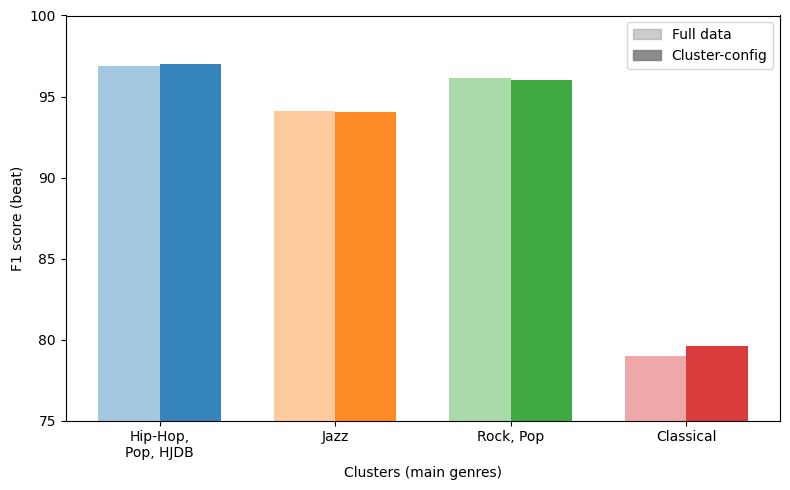

In [14]:
bar_plot_per_cluster (df_path = "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", json_path =  "json_val_scores",
                       clusters = [1,2,3,4], seeds =[0,1,2] , cluster_config= "clusters4_layer12")

In [46]:
df_path = "data_cluster_assignments/df_cmeans_12_4clusters_new.csv"
json_path =  "json_val_scores"
clusters = [1,2,3,4]
seeds =[0,1,2]
cluster_config= "clusters4_layer12"
full_scores = {}
config_scores = {}
cluster_labels = []   # for x-tick labels (genres per cluster)

for cluster in clusters:
    scores_full = get_restults_per_cluster(
        json_path, cluster=cluster, seeds=seeds,
        df_path=df_path, full=True, per_cluster=True
    )
    scores_config, cluster_genres = get_restults_per_cluster(
        json_path, cluster=cluster, seeds=seeds,
        df_path=df_path, full=False, cluster_config=cluster_config
    )

    full_scores[cluster] = gete_f1_av(scores_full)
    config_scores[cluster] = gete_f1_av(scores_config)

    # assuming cluster_genres is a list of strings; adjust if needed
    cluster_labels.append(cluster_genres)


220
220
genres are Hip-Hop + Pop + HJDB
123
123
genres are Jazz
153
153
genres are Rock + Pop
106
106
genres are Classical


220
220
genres are Hip-Hop + Pop + HJDB
123
123
genres are Jazz
153
153
genres are Rock + Pop
106
106
genres are Classical


(<Figure size 800x500 with 1 Axes>,
 <Axes: xlabel='Clusters (main genres)', ylabel='F1 score (beat)'>)

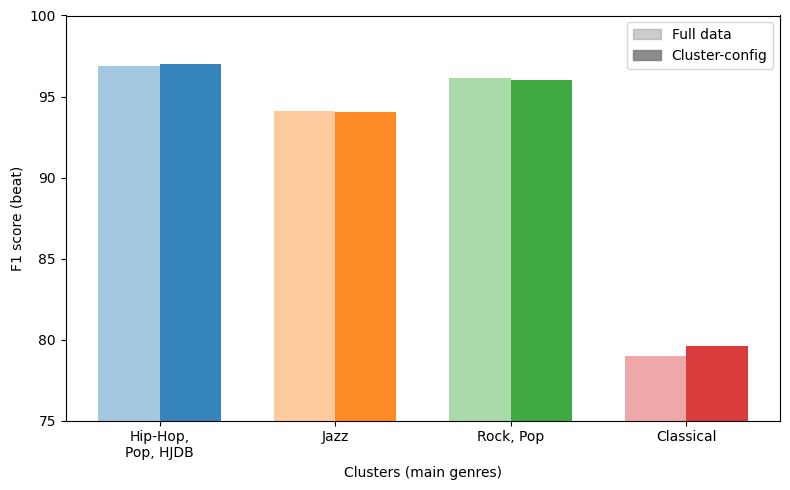

In [45]:
bar_plot_per_cluster (df_path = "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", json_path =  "json_val_scores",
                       clusters = [1,2,3,4], seeds =[0,1,2] , cluster_config= "clusters4_layer12")

347
347
genres are Pop + Groove + Rock + Hip-Hop
209
209
genres are Classical + Jazz


([96.62956553415377, 86.55287962499914],
 [96.47858769862778, 86.30690941828051])

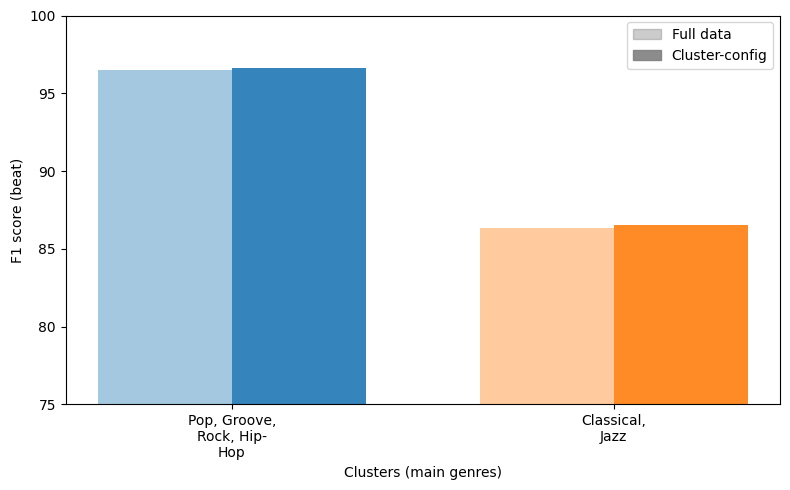

In [16]:
bar_plot_per_cluster (df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv", json_path =  "json_val_scores",
                       clusters = [1,2], seeds =[0,1,2] , cluster_config= "clusters2_layer6")

184
184
genres are Classical + Groove + Jazz
204
204
genres are Pop + Rock + HJDB + Hip-Hop
168
168
genres are Jazz + Pop + Rock


(<Figure size 800x500 with 1 Axes>,
 <Axes: xlabel='Clusters (main genres)', ylabel='F1 score (beat)'>)

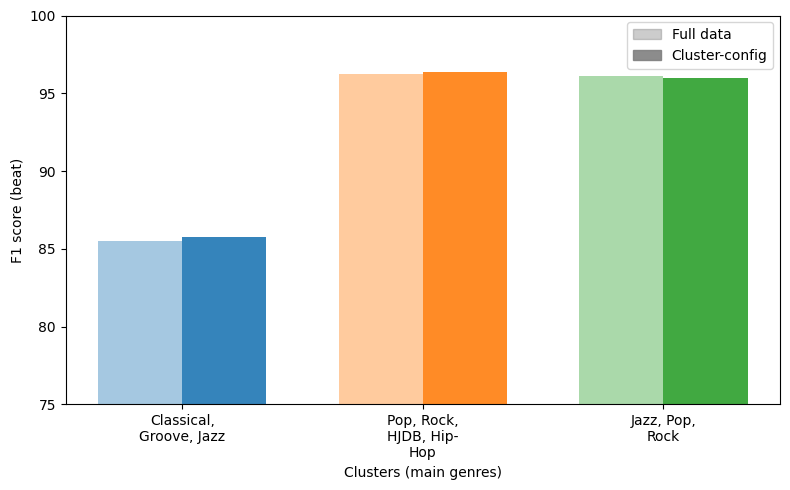

In [44]:
bar_plot_per_cluster (df_path = "data_cluster_assignments/df_raw_113_3clusters_new.csv", json_path =  "json_val_scores",
                       clusters = [1,2, 3], seeds =[0,1,2] , cluster_config= "clusters3_layer113")

In [97]:

json_path = "json_val_scores"
scores = get_restults_per_cluster (json_path,  cluster = 4, seeds = [0,1,2], df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", full = True, per_cluster=True )
df = pd.DataFrame(scores)

summary = pd.DataFrame({
    "mean": df.mean(),
    "std": df.std()
})
summary.loc["F-measure_beat", "mean"]

genres are 4 (Classical)
106


78.95359938663142

In [102]:
scores = get_restults_per_cluster (json_path,  cluster = 4, seeds = [0,1,2], df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", full =False,cluster_config="clusters4_layer12")
df = pd.DataFrame(scores)

summary = pd.DataFrame({
    "mean": df.mean(),
    "std": df.std()
})
summary

genres are 4 (Classical)
106


,mean,std
F-measure_beat,79.591125,0.690399
Cemgil_beat,70.760420,0.844271
CMLt_beat,62.908401,1.365148
AMLt_beat,67.816725,1.246955
F-measure_downbeat,60.752605,0.594592
Cemgil_downbeat,56.366088,0.589425
CMLt_downbeat,29.759234,0.761852
AMLt_downbeat,47.179438,0.859891


In [107]:
len(scores)

3

In [86]:
cluster_config = "clusters4_layer12"
cluster_number = 1
folder = os.path.join(json_path, cluster_config, f"{cluster_number}")
print(folder)
file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]   # f"best_checkpoint-seed{seed}" in file best_checkpoint-seed

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
clsuter_keys = set(json1_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json1_data).T
df.head()

json_val_scores/clusters4_layer12/1
220


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
ballroom/ballroom_Albums-Cafe_Paradiso-06/track.npy,1.000000,0.892596,1.000000,1.000000,1.000000,0.877787,1.000000,1.000000
ballroom/ballroom_Albums-Cafe_Paradiso-07/track.npy,0.990291,0.933492,0.980769,0.980769,1.000000,0.959112,1.000000,1.000000
ballroom/ballroom_Albums-Fire-02/track.npy,1.000000,0.944806,1.000000,1.000000,1.000000,0.942174,1.000000,1.000000
ballroom/ballroom_Albums-Latin_Jam2-02/track.npy,1.000000,0.972828,1.000000,1.000000,0.952381,0.911810,0.909091,0.909091
ballroom/ballroom_Albums-Latin_Jam2-06/track.npy,0.990654,0.972931,0.981481,0.981481,0.962963,0.947422,0.928571,0.928571


In [ ]:
def get_total_results (seeds, json_val_path, cluster_config, cluster_numbers):
    df_list = []
    for seed in seeds:
        df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers)
        df_full = construct_df_full_data (json_val_path, seed=seed, rename_columns="baseline")
        diff_dict = get_performance_differences (df_total, df_full)
        diff_dict_renamed = rename_keys_dict(diff_dict)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(diff_dict_renamed, orient="index", columns=[f"Value_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    return df_result

In [ ]:
import json
import os
json_val_path = "json_val_scores/clusters4_layer12"
keys = {}
for i in range (1,5):
    folder = os.path.join(json_val_path, str(i))
    file_scores = [file for file in os.listdir(folder) if "best_checkpoint" in file][0]

    json_file = open(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    keys[i] = clsuter_keys
print(keys)

In [53]:
df1 = construct_df_clsuter_data(json_val_path, seed=0,cluster_config = "clusters2_layer6", cluster_number= 1,rename_columns= "clusters2_layer6")
df2 = construct_df_clsuter_data(json_val_path, seed=0,cluster_config = "clusters2_layer6", cluster_number= 2,rename_columns= "clusters2_layer6")
df_total = pd.concat([df1, df2], axis=0)
cols_f = [col for col in df_total.columns if "F-measure" in col]
df_total_f1 = df_total[cols_f]
df_total_f1 
means_total = (df_total.mean()* 100).to_dict()
means_total

347
209


{'F-measure_beat_clusters2_layer60': 92.87020670156396,
 'Cemgil_beat_clusters2_layer60': 85.10952250954362,
 'CMLt_beat_clusters2_layer60': 85.21058281061691,
 'AMLt_beat_clusters2_layer60': 89.36609345033831,
 'F-measure_downbeat_clusters2_layer60': 85.43487355624686,
 'Cemgil_downbeat_clusters2_layer60': 79.45757279218076,
 'CMLt_downbeat_clusters2_layer60': 72.77422067995289,
 'AMLt_downbeat_clusters2_layer60': 80.82696071845093}

In [54]:
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
cols_f = [col for col in df_full.columns if "F-measure" in col]
df_fulll_f1 = df_full[cols_f]
means_full =(df_full.mean()*  100).to_dict()
means_full

556


{'F-measure_beat_baseline0': 92.67559037887163,
 'Cemgil_beat_baseline0': 84.89799383668344,
 'CMLt_beat_baseline0': 84.60569681054906,
 'AMLt_beat_baseline0': 88.71768403791125,
 'F-measure_downbeat_baseline0': 85.11133744115672,
 'Cemgil_downbeat_baseline0': 79.10203722776434,
 'CMLt_downbeat_baseline0': 72.10066458824532,
 'AMLt_downbeat_baseline0': 79.43592982857372}

In [55]:
diff_dict = {list(means_total.keys())[i]: means_total[list(means_total.keys())[i]] - means_full[list(means_full.keys())[i]] for i in range(len(means_full))}
diff_dict

{'F-measure_beat_clusters2_layer60': 0.1946163226923261,
 'Cemgil_beat_clusters2_layer60': 0.21152867286018306,
 'CMLt_beat_clusters2_layer60': 0.6048860000678502,
 'AMLt_beat_clusters2_layer60': 0.648409412427057,
 'F-measure_downbeat_clusters2_layer60': 0.32353611509013547,
 'Cemgil_downbeat_clusters2_layer60': 0.35553556441641376,
 'CMLt_downbeat_clusters2_layer60': 0.6735560917075674,
 'AMLt_downbeat_clusters2_layer60': 1.3910308898772143}

In [85]:
df_total = construct_total_df (json_val_path, seed=0, cluster_config="clusters2_layer6", cluster_numbers=[1,2])
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
diff_dict = get_performance_differences (df_total, df_full)
diff_dict

347
209
Final size of df is 556
556


{'F-measure_beat_clusters2_layer6_0': 0.19461632269238294,
 'Cemgil_beat_clusters2_layer6_0': 0.211528672860112,
 'CMLt_beat_clusters2_layer6_0': 0.6048860000678076,
 'AMLt_beat_clusters2_layer6_0': 0.6484094124270428,
 'F-measure_downbeat_clusters2_layer6_0': 0.3235361150901497,
 'Cemgil_downbeat_clusters2_layer6_0': 0.35553556441637113,
 'CMLt_downbeat_clusters2_layer6_0': 0.6735560917075816,
 'AMLt_downbeat_clusters2_layer6_0': 1.3910308898772996}

In [17]:
df_total = construct_total_df (json_val_path, seed=0, cluster_config="clusters4_layer12", cluster_numbers=[1,2, 3,4])
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
diff_dict0 = get_performance_differences (df_total, df_full)
diff_dict0

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556


{'F-measure_beat_clusters4_layer12_0': 0.17011146854920867,
 'Cemgil_beat_clusters4_layer12_0': 0.21154820779605643,
 'CMLt_beat_clusters4_layer12_0': 0.6858410904917349,
 'AMLt_beat_clusters4_layer12_0': 0.5422025666788244,
 'F-measure_downbeat_clusters4_layer12_0': 0.2828661715811478,
 'Cemgil_downbeat_clusters4_layer12_0': 0.23577475631742573,
 'CMLt_downbeat_clusters4_layer12_0': 0.681876299303525,
 'AMLt_downbeat_clusters4_layer12_0': 0.9236112107499537}

In [7]:
#df0 = pd.DataFrame.from_dict(diff_dict0, orient='index', columns = ["Values0"])
df1= pd.DataFrame.from_dict(list(diff_dict1.items()), columns = ["Metric", "Value"] )
# df_res =  pd.concat([df0, df1], axis=0)
# df_res
df1

ValueError: cannot use columns parameter with orient='columns'

In [13]:
df1 = pd.DataFrame(list(diff_dict1.items()), columns=["Metric", "Value"])
df1

,Metric,Value
0,F-measure_beat_clusters4_layer12_1,-0.045774
1,Cemgil_beat_clusters4_layer12_1,-0.146955
2,CMLt_beat_clusters4_layer12_1,-0.323932
3,AMLt_beat_clusters4_layer12_1,-0.020322
4,F-measure_downbeat_clusters4_layer12_1,0.009791
5,Cemgil_downbeat_clusters4_layer12_1,-0.137542
6,CMLt_downbeat_clusters4_layer12_1,-0.178244
7,AMLt_downbeat_clusters4_layer12_1,-0.558642


In [14]:
diff_dict1.items()

dict_items([('F-measure_beat_clusters4_layer12_1', -0.04577390748724497), ('Cemgil_beat_clusters4_layer12_1', -0.1469553476583485), ('CMLt_beat_clusters4_layer12_1', -0.32393166924647687), ('AMLt_beat_clusters4_layer12_1', -0.020321947870471035), ('F-measure_downbeat_clusters4_layer12_1', 0.009791016016123422), ('Cemgil_downbeat_clusters4_layer12_1', -0.13754175909721766), ('CMLt_downbeat_clusters4_layer12_1', -0.17824391657016747), ('AMLt_downbeat_clusters4_layer12_1', -0.55864231428464)])

In [23]:
dict1_new = {}
for key in diff_dict1.keys():
    new_key = "_".join(key.split("_")[:-1])
    dict1_new [new_key] = diff_dict1[key]
dict1_new

{'F-measure_beat_clusters4_layer12': -0.04577390748724497,
 'Cemgil_beat_clusters4_layer12': -0.1469553476583485,
 'CMLt_beat_clusters4_layer12': -0.32393166924647687,
 'AMLt_beat_clusters4_layer12': -0.020321947870471035,
 'F-measure_downbeat_clusters4_layer12': 0.009791016016123422,
 'Cemgil_downbeat_clusters4_layer12': -0.13754175909721766,
 'CMLt_downbeat_clusters4_layer12': -0.17824391657016747,
 'AMLt_downbeat_clusters4_layer12': -0.55864231428464}

In [20]:
import os
import json
json_val_path = "json_val_scores"
df_total = construct_total_df (json_val_path, seed=1, cluster_config="clusters4_layer12", cluster_numbers=[1,2, 3,4])
df_full = construct_df_full_data (json_val_path, seed=1, rename_columns="baseline")
diff_dict1 = get_performance_differences (df_total, df_full)
diff_dict1

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556


{'F-measure_beat_clusters4_layer12_1': -0.04577390748724497,
 'Cemgil_beat_clusters4_layer12_1': -0.1469553476583485,
 'CMLt_beat_clusters4_layer12_1': -0.32393166924647687,
 'AMLt_beat_clusters4_layer12_1': -0.020321947870471035,
 'F-measure_downbeat_clusters4_layer12_1': 0.009791016016123422,
 'Cemgil_downbeat_clusters4_layer12_1': -0.13754175909721766,
 'CMLt_downbeat_clusters4_layer12_1': -0.17824391657016747,
 'AMLt_downbeat_clusters4_layer12_1': -0.55864231428464}

In [42]:
def rename_keys_dict(d):
    dict_new = {}
    for key in d.keys():
        new_key = "_".join(key.split("_")[:-1])
        dict_new [new_key] = d[key]
    return dict_new
def get_total_results (seeds, json_val_path, cluster_config, cluster_numbers):
    df_list = []
    for seed in seeds:
        df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers)
        df_full = construct_df_full_data (json_val_path, seed=seed, rename_columns="baseline")
        diff_dict = get_performance_differences (df_total, df_full)
        diff_dict_renamed = rename_keys_dict(diff_dict)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(diff_dict_renamed, orient="index", columns=[f"Value_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    return df_result

In [45]:
df_total = get_total_results (seeds = [0,1], json_val_path = "json_val_scores", cluster_config="clusters4_layer12", cluster_numbers=[1,2, 3,4])
df_total.mean(axis = 1)
df_total

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556
json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556


,Value_0,Value_1
F-measure_beat_clusters4_layer12,0.170111,-0.045774
Cemgil_beat_clusters4_layer12,0.211548,-0.146955
CMLt_beat_clusters4_layer12,0.685841,-0.323932
AMLt_beat_clusters4_layer12,0.542203,-0.020322
F-measure_downbeat_clusters4_layer12,0.282866,0.009791
Cemgil_downbeat_clusters4_layer12,0.235775,-0.137542
CMLt_downbeat_clusters4_layer12,0.681876,-0.178244
AMLt_downbeat_clusters4_layer12,0.923611,-0.558642


In [ ]:
import os
import json
json_val_path = "json_val_scores"
df_total = construct_total_df (json_val_path, seed=0, cluster_config="clusters3_layer113", cluster_numbers=[1,2, 3])
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
diff_dict = get_performance_differences (df_total, df_full)
diff_dict

json_val_scores/clusters3_layer113/1
184
json_val_scores/clusters3_layer113/2
204
json_val_scores/clusters3_layer113/3
168
Final size of df is 556
556


{'F-measure_beat_clusters3_layer113_0': -0.009816996519390386,
 'Cemgil_beat_clusters3_layer113_0': -0.23713233829714397,
 'CMLt_beat_clusters3_layer113_0': 0.19418560072544722,
 'AMLt_beat_clusters3_layer113_0': 0.03538814802558932,
 'F-measure_downbeat_clusters3_layer113_0': 0.20640883754387573,
 'Cemgil_downbeat_clusters3_layer113_0': -0.14219493196397082,
 'CMLt_downbeat_clusters3_layer113_0': 0.4797200504718404,
 'AMLt_downbeat_clusters3_layer113_0': 0.33998351550118855}

In [ ]:
df_total.isna() 

,F-measure_beat_clusters3_layer113_0,Cemgil_beat_clusters3_layer113_0,CMLt_beat_clusters3_layer113_0,AMLt_beat_clusters3_layer113_0,F-measure_downbeat_clusters3_layer113_0,Cemgil_downbeat_clusters3_layer113_0,CMLt_downbeat_clusters3_layer113_0,AMLt_downbeat_clusters3_layer113_0
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_874_BianF01/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,False,False,False,False,False,False,False,False
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,False,False,False,False,False,False,False,False
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,False,False,False,False,False,False,False,False
tapcorrect/093_youtube_C1lbOgBtE3w/track.npy,False,False,False,False,False,False,False,False


In [70]:
df2

,F-measure_beat_clusters4_layer120,Cemgil_beat_clusters4_layer120,CMLt_beat_clusters4_layer120,AMLt_beat_clusters4_layer120,F-measure_downbeat_clusters4_layer120,Cemgil_downbeat_clusters4_layer120,CMLt_downbeat_clusters4_layer120,AMLt_downbeat_clusters4_layer120
ballroom/ballroom_Albums-Cafe_Paradiso-01/track.npy,1.000000,0.922979,1.000000,1.000000,1.000000,0.896015,1.000000,1.000000
ballroom/ballroom_Albums-Cafe_Paradiso-07/track.npy,1.000000,0.974899,1.000000,1.000000,1.000000,0.995267,1.000000,1.000000
ballroom/ballroom_Albums-Cafe_Paradiso-12/track.npy,1.000000,0.954732,1.000000,1.000000,0.952381,0.898297,0.909091,0.909091
ballroom/ballroom_Albums-Commitments-08/track.npy,0.971014,0.947054,0.929577,0.929577,0.969697,0.937109,0.941176,0.941176
ballroom/ballroom_Albums-Commitments-11/track.npy,1.000000,0.936685,1.000000,1.000000,1.000000,0.952677,1.000000,1.000000
...,...,...,...,...,...,...,...,...
tapcorrect/045_youtube_SYUgGs9IStY/track.npy,0.781570,0.776370,0.280112,0.562363,0.642857,0.704612,0.052632,0.684211
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,1.000000,0.951452,1.000000,1.000000,0.862500,0.831361,0.627907,0.627907
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,0.963438,0.876585,0.930521,0.930521,0.949495,0.847326,0.908213,0.908213
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,0.996870,0.965523,0.993760,0.993760,0.996865,0.958880,0.993750,0.993750


In [73]:
len(set(df1.index)  & set(df2.index))

28

In [67]:
idncies_repeat = [ind for ind in df_total.index.to_list() if df_total.index.to_list().count(ind) >1]
len(idncies_repeat)

56

In [11]:
mapping

{'F-measure_beat_full_data_seed0': 'F-measure_beat',
 'Cemgil_beat_full_data_seed0': 'Cemgil_beat',
 'CMLt_beat_full_data_seed0': 'CMLt_beat',
 'AMLt_beat_full_data_seed0': 'AMLt_beat',
 'F-measure_downbeat_full_data_seed0': 'F-measure_downbeat',
 'Cemgil_downbeat_full_data_seed0': 'Cemgil_downbeat',
 'CMLt_downbeat_full_data_seed0': 'CMLt_downbeat',
 'AMLt_downbeat_full_data_seed0': 'AMLt_downbeat'}

In [12]:
seed = 0
mapping = { col: f"{col}_full_data_seed{seed}" for col in df.columns}
df = df.rename(columns=mapping)
df

,F-measure_beat_full_data_seed0,Cemgil_beat_full_data_seed0,CMLt_beat_full_data_seed0,AMLt_beat_full_data_seed0,F-measure_downbeat_full_data_seed0,Cemgil_downbeat_full_data_seed0,CMLt_downbeat_full_data_seed0,AMLt_downbeat_full_data_seed0
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,0.990689,0.946179,0.977695,0.977695,0.554545,0.619217,0.045752,0.437908
asap/Bach_Fugue_bwv_874_BianF01/track.npy,0.103806,0.089323,0.000000,0.606218,0.040201,0.036285,0.000000,0.000000
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,0.666667,0.768584,0.000000,0.984536,0.571429,0.662933,0.000000,0.600000
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,0.664384,0.763135,0.000000,0.969231,0.548780,0.627003,0.000000,0.586207
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,0.736842,0.717897,0.361111,0.385366,0.355932,0.387693,0.000000,0.173913
...,...,...,...,...,...,...,...,...
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,1.000000,0.952138,1.000000,1.000000,0.867925,0.831172,0.647059,0.647059
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,0.960358,0.864980,0.924784,0.924784,0.930693,0.827054,0.874419,0.874419
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,0.996870,0.969499,0.993760,0.993760,0.996865,0.965355,0.993750,0.993750
tapcorrect/093_youtube_C1lbOgBtE3w/track.npy,0.909890,0.838151,0.690909,0.690909,0.803089,0.766750,0.348387,0.478261


In [7]:
import json
import os
import pandas as pd
json_val_path = "json_val_scores"
keys = {}

folder = os.path.join(json_val_path, "full_data")
file_scores = [file for file in os.listdir(folder) if "best-seed0" in file][0]

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
clsuter_keys = set(json1_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json1_data).T
df

556


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,0.990689,0.946179,0.977695,0.977695,0.554545,0.619217,0.045752,0.437908
asap/Bach_Fugue_bwv_874_BianF01/track.npy,0.103806,0.089323,0.000000,0.606218,0.040201,0.036285,0.000000,0.000000
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,0.666667,0.768584,0.000000,0.984536,0.571429,0.662933,0.000000,0.600000
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,0.664384,0.763135,0.000000,0.969231,0.548780,0.627003,0.000000,0.586207
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,0.736842,0.717897,0.361111,0.385366,0.355932,0.387693,0.000000,0.173913
...,...,...,...,...,...,...,...,...
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,1.000000,0.952138,1.000000,1.000000,0.867925,0.831172,0.647059,0.647059
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,0.960358,0.864980,0.924784,0.924784,0.930693,0.827054,0.874419,0.874419
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,0.996870,0.969499,0.993760,0.993760,0.996865,0.965355,0.993750,0.993750
tapcorrect/093_youtube_C1lbOgBtE3w/track.npy,0.909890,0.838151,0.690909,0.690909,0.803089,0.766750,0.348387,0.478261


In [6]:
json1_data

{'asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy': {'F-measure_beat': 0.9906890130353817,
  'Cemgil_beat': 0.9461791100978764,
  'CMLt_beat': 0.9776951672862454,
  'AMLt_beat': 0.9776951672862454,
  'F-measure_downbeat': 0.5545454545454546,
  'Cemgil_downbeat': 0.6192171586932619,
  'CMLt_downbeat': 0.0457516339869281,
  'AMLt_downbeat': 0.43790849673202614},
 'asap/Bach_Fugue_bwv_874_BianF01/track.npy': {'F-measure_beat': 0.10380622837370242,
  'Cemgil_beat': 0.08932329235123523,
  'CMLt_beat': 0.0,
  'AMLt_beat': 0.6062176165803109,
  'F-measure_downbeat': 0.04020100502512563,
  'Cemgil_downbeat': 0.03628480207402904,
  'CMLt_downbeat': 0.0,
  'AMLt_downbeat': 0.0},
 'asap/Bach_Fugue_bwv_874_Kurz01M/track.npy': {'F-measure_beat': 0.6666666666666666,
  'Cemgil_beat': 0.7685835752035493,
  'CMLt_beat': 0.0,
  'AMLt_beat': 0.9845360824742269,
  'F-measure_downbeat': 0.5714285714285715,
  'Cemgil_downbeat': 0.6629334122797284,
  'CMLt_downbeat': 0.0,
  'AMLt_downbeat': 0.6},
 'asap/Bach_F

# HPO

In [8]:
import optuna
def filter_optuna_study(study):
    df = study.trials_dataframe()
    df_filtered = df[df["state"].isin(["COMPLETE", "PRUNED"]) ]
    date_cols = [col for col in df_filtered.columns if "datetime" in col or "duration" in col]
    df_filtered = df_filtered.drop(columns = date_cols, axis = 1)

    df_filtered = df_filtered.reset_index()
    df_filtered = df_filtered.drop(columns = ["index"], axis = 1)
    df_filtered["value"] = df_filtered["value"]* 100
    print(f"Size of filtered df is {len(df_filtered)}")
    return df_filtered
from optuna.distributions import (
    UniformDistribution, LogUniformDistribution,
    IntUniformDistribution, CategoricalDistribution
)

def extract_search_space(study):
    space = {}
    for trial in study.trials:
        for name, dist in trial.distributions.items():
            if name in space:
                continue
            if hasattr(dist, "low"):
                space[name] = (dist.low, dist.high)
            elif isinstance(dist, CategoricalDistribution):
                space[name] = list(dist.choices)
    return space
def get_pruned(df, tail = 10):
    last_df = df.tail(tail)
    df_pruned_last = last_df[last_df["state"] == "PRUNED"]
    print(f"Percentage of pruned runs is {len(df_pruned_last) / len(last_df)* 100}% ")
def get_study_info(study_name, storage_path, baseline_value = None, pruned = True, tail= None):
    study = optuna.load_study(
        study_name=study_name,
        storage=storage_path
    )
    df_filtered = filter_optuna_study(study)
    search_space = extract_search_space(study)
    print(search_space)
    if pruned:
        get_pruned(df_filtered, tail = tail)
    if baseline_value is not None:
        
        df_filtered["diff"] = df_filtered["value"].apply(lambda x: x - baseline_value)
        
    indices = df_filtered["value"].nlargest(10).index
    df_filtered = df_filtered.loc[indices]
    return df_filtered, search_space
def print_top_trials_params(study_name, storage_path, top_k = 3):
    study = optuna.load_study(
        study_name=study_name,
        storage=storage_path
    )
    top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:top_k]

    for i, t in enumerate(top_trials, 1):
        print(f"Rank {i}: Trial #{t.number}")
        print(f"  Value: {t.value}")
        print(f"  Params:")
        for k, v in t.params.items():
            print(f"    {k}: {v}")
        print("-----")
def print_top_k(study_name, storage_path, top_k):
    study = optuna.load_study(study_name=study_name, storage=storage_path)
    top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:top_k]

    for i, t in enumerate(top_trials, 1):
        print(f"Rank {i}: Trial #{t.number}")
        print(f"  Value: {t.value}")
        print(f"  Params:")
        for k, v in t.params.items():
            print(f"    {k}: {v}")
        print("-----")

/home/ui556004/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Full data

In [59]:
import optuna
import pandas as pd
study = optuna.load_study(
    study_name="hpo_full",
    storage="sqlite:///optuna.db"
)

# Convert to pandas DataFrame
df = study.trials_dataframe()
df_filtered = df[df["state"].isin(["COMPLETE", "PRUNED"]) ]
date_cols = [col for col in df_filtered.columns if "datetime" in col or "duration" in col]
df_filtered = df_filtered.drop(columns = date_cols, axis = 1)

df_filtered = df_filtered.reset_index()
df_filtered = df_filtered.drop(columns = ["index"], axis = 1)
df_filtered.head(10)

,number,value,params_batch_size,params_lr,params_weight_decay,state
0,0,0.878053,4,0.000122,0.071145,COMPLETE
1,1,0.757172,4,0.000028,0.000149,COMPLETE
2,5,0.673410,4,0.000011,0.081232,COMPLETE
3,6,0.777657,4,0.000034,0.000818,COMPLETE
4,7,0.883534,16,0.000597,0.000262,COMPLETE
5,8,0.879943,8,0.001903,0.000397,COMPLETE
6,9,0.882633,16,0.000580,0.000325,COMPLETE
7,10,0.797312,8,0.002223,0.000820,PRUNED
8,11,0.595752,8,0.000023,0.003059,PRUNED
9,12,0.900020,8,0.000838,0.000861,COMPLETE


In [60]:
len(df_filtered)

50

In [61]:
indices = df_filtered["value"].nlargest(10).index
df_filtered.loc[indices]

,number,value,params_batch_size,params_lr,params_weight_decay,state
22,26,0.901146,4,0.000316,0.001294,COMPLETE
44,50,0.900029,4,0.000505,0.001337,COMPLETE
9,12,0.900020,8,0.000838,0.000861,COMPLETE
42,48,0.899722,8,0.001117,0.000500,COMPLETE
33,38,0.899698,4,0.000511,0.002507,COMPLETE
28,33,0.898988,4,0.000498,0.002382,COMPLETE
39,45,0.898479,8,0.000827,0.000342,COMPLETE
29,34,0.897092,4,0.000349,0.005386,COMPLETE
35,40,0.896786,4,0.000444,0.001702,COMPLETE
25,29,0.896767,4,0.000659,0.000120,COMPLETE


In [74]:
top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:3]

for i, t in enumerate(top_trials, 1):
    print(f"Rank {i}: Trial #{t.number}")
    print(f"  Value: {t.value}")
    print(f"  Params:")
    for k, v in t.params.items():
        print(f"    {k}: {v}")
    print("-----")

Rank 1: Trial #26
  Value: 0.9011459350585938
  Params:
    lr: 0.0003158311397501126
    weight_decay: 0.0012940118614123087
    batch_size: 4
-----
Rank 2: Trial #50
  Value: 0.9000294804573059
  Params:
    lr: 0.0005048069270599075
    weight_decay: 0.0013370653462673073
    batch_size: 4
-----
Rank 3: Trial #12
  Value: 0.9000197649002075
  Params:
    lr: 0.0008382273168274294
    weight_decay: 0.0008612579192594886
    batch_size: 8
-----


In [23]:
ind = df_filtered["value"].argmax()
df_filtered.iloc[ind]

number                       26
value                  0.901146
params_batch_size             4
params_lr              0.000316
params_weight_decay    0.001294
state                  COMPLETE
Name: 22, dtype: object

In [26]:
last_df = df_filtered.tail(10)
last_df

,number,value,params_batch_size,params_lr,params_weight_decay,state
40,46,0.896443,8,0.001276,0.001596,COMPLETE
41,47,0.778060,8,0.000676,0.000251,PRUNED
42,48,0.899722,8,0.001117,0.000500,COMPLETE
43,49,0.424236,8,0.005323,0.000563,PRUNED
44,50,0.900029,4,0.000505,0.001337,COMPLETE
45,52,0.893914,8,0.000739,0.000710,COMPLETE
46,53,0.781912,4,0.000214,0.000872,PRUNED
47,54,0.578310,4,0.001469,0.001171,PRUNED
48,55,0.760642,16,0.007446,0.017315,PRUNED
49,56,0.727528,16,0.000438,0.001007,PRUNED


In [6]:
df_complete = df_filtered[df_filtered["state"] == "COMPLETE"]
last_complete_df = df_complete.tail(10)
last_complete_df

,number,value,params_batch_size,params_lr,params_weight_decay,state
33,33,0.898988,4,0.000498,0.002382,COMPLETE
34,34,0.897092,4,0.000349,0.005386,COMPLETE
38,38,0.899698,4,0.000511,0.002507,COMPLETE
40,40,0.896786,4,0.000444,0.001702,COMPLETE
44,44,0.895133,4,0.000678,0.002420,COMPLETE
45,45,0.898479,8,0.000827,0.000342,COMPLETE
46,46,0.896443,8,0.001276,0.001596,COMPLETE
48,48,0.899722,8,0.001117,0.000500,COMPLETE
50,50,0.900029,4,0.000505,0.001337,COMPLETE
52,52,0.893914,8,0.000739,0.000710,COMPLETE


In [7]:
def describe_column (df,column, multiply = False, complete = False):
    df_filtered = df[df["state"] == "COMPLETE"] if complete else df.copy()
    if multiply:
        values = df_filtered [column]*100
    else:
        values = df_filtered [column].copy()
    mean = values.mean()
    std =values.std()
    round_value = 2 if multiply else 5
    return round(mean, round_value ), round(std, round_value )

In [27]:
columns = ["value", "params_batch_size", "params_lr", "params_weight_decay"]
for column in columns:
    multiply = True if column == "value" else False
    mean, std = describe_column(last_complete_df, column, multiply, complete=False)
    print(f"Results for column {column}")
    print(f"{mean} +- {std}")


Results for column value
89.76 +- 0.21
Results for column params_batch_size
5.6 +- 2.06559
Results for column params_lr
0.00069 +- 0.0003
Results for column params_weight_decay
0.00189 +- 0.00146


In [28]:
last_df_complete = last_df[last_df["state"] == "COMPLETE"]
res =last_df_complete["value"].describe()*100

In [10]:
res["mean"]

89.75273221731186

In [29]:
df_pruned_last = last_df[last_df["state"] == "PRUNED"]
print(f"Percentage of pruned runs is {len(df_pruned_last) / len(last_df)* 100}% ")

Percentage of pruned runs is 60.0% 


In [36]:
from optuna.importance import get_param_importances, FanovaImportanceEvaluator
importance = optuna.importance.get_param_importances(
            study, evaluator=FanovaImportanceEvaluator()
        )
for i in range (9):
    new_importance = optuna.importance.get_param_importances(
            study, evaluator=FanovaImportanceEvaluator()
        )
    importance = {key: value + new_importance[key]  for key, value in importance.items()}
importance_norm = {key: value / 10 for key, value in importance.items()}
print(importance_norm)

{'lr': 0.8793886882831676, 'weight_decay': 0.07408247056937449, 'batch_size': 0.04652884114745773}


In [38]:
sum(list(importance_norm.values()))

0.9999999999999998

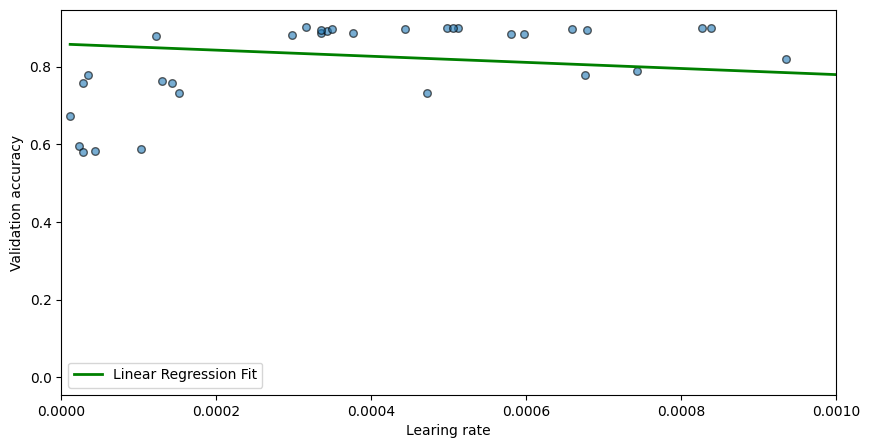

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Assume df is already loaded with columns "dropout_top" and "eval/accuracy"
x = df_filtered["params_lr"].values
y = df_filtered["value"].values

# Fit linear regression
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)
coef = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

# Prepare data for plotting
order = np.argsort(x)
x_sorted = x[order]
y_pred_sorted = model.predict(x_sorted.reshape(-1, 1))

# Compute rolling mean for trend line
window = max(8, len(x) // 20)
y_smooth = pd.Series(y[order]).rolling(window= 20, min_periods=4, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, alpha=0.6, edgecolors='k', s=30)
#ax.plot(x_sorted, y_smooth, lw=2, label='Rolling Mean Trend')
ax.plot(x_sorted, y_pred_sorted, lw=2, label='Linear Regression Fit', color = "g")

ax.set_xlabel("Learing rate")
ax.set_xlim(0, 0.001)
ax.set_ylabel("Validation accuracy")
#ax.set_title("Dropout vs Eval/Accuracy with Linear Regression")
ax.legend()
#plt.savefig("figures/nas_frozen_layesrs.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [37]:
import pandas as pd

columns = ["val_F-measure_beat", "val_F-measure_downbeat", "Name"]
df = pd.read_csv("wandb_csvs/wandb_hpo_full.csv")
df = df.dropna(how='all')
df = df[df["State"] == "finished"]
df[columns].head()

,val_F-measure_beat,val_F-measure_downbeat,Name
0,0.727528,0.538627,trial_56
1,0.760642,0.547290,trial_55
2,0.578310,0.295710,trial_54
3,0.781912,0.605683,trial_53
4,0.893914,0.799895,trial_52


In [38]:
df.head()

,Name,State,val_F-measure_beat,lr,Group,Runtime,cluster_number,Created,freeze_layers,ckpt_epoch,...,stage,use_early_stopping,checkpoints_folder,clustering_config,full_data,num_trials,sampler_path,trial_number,val_F-measure_beat_baseline,weight_decay
0,trial_56,finished,0.727528,0.000438,hpo_full,546,0,2025-11-30T00:57:10.000Z,NaN,NaN,...,NaN,False,NaN,NaN,NaN,5,sampler_hpo_full.pkl,NaN,NaN,0.001007
1,trial_55,finished,0.760642,0.007446,hpo_full,690,0,2025-11-30T00:43:50.000Z,NaN,NaN,...,NaN,False,NaN,NaN,NaN,5,sampler_hpo_full.pkl,NaN,NaN,0.017315
2,trial_54,finished,0.578310,0.001469,hpo_full,713,0,2025-11-30T00:30:05.000Z,NaN,NaN,...,NaN,False,NaN,NaN,NaN,5,sampler_hpo_full.pkl,NaN,NaN,0.001171
3,trial_53,finished,0.781912,0.000214,hpo_full,800,0,2025-11-30T00:14:48.000Z,NaN,NaN,...,NaN,False,NaN,NaN,NaN,5,sampler_hpo_full.pkl,NaN,NaN,0.000872
4,trial_52,finished,0.893914,0.000739,hpo_full,2642,0,2025-11-29T23:30:09.000Z,NaN,NaN,...,NaN,False,NaN,NaN,NaN,5,sampler_hpo_full.pkl,NaN,NaN,0.000710


In [39]:
from scipy import stats
res_spearman = stats.spearmanr(df["val_F-measure_beat"].values, df["val_F-measure_downbeat"].values)
res_pearson = stats.pearsonr(df["val_F-measure_beat"].values, df["val_F-measure_downbeat"].values)
res_spearman, res_pearson

(SignificanceResult(statistic=0.9839487726787619, pvalue=4.295408117762366e-39),
 PearsonRResult(statistic=0.9503088698068888, pvalue=5.383736919940379e-27))

In [34]:
df["val_F-measure_beat"].values

array([0.72752774, 0.76064199, 0.57831001, 0.78191173, 0.89391428,
       0.90002948, 0.42423648, 0.89972246, 0.77806008, 0.89644307,
       0.89847863, 0.8951335 , 0.58135951, 0.76100719, 0.89678627,
       0.58817691, 0.8996985 , 0.61246222, 0.75847936, 0.76265812,
       0.89709222, 0.89898795, 0.57901281, 0.72954828, 0.89676726,
       0.89292353, 0.89056361, 0.90114594, 0.88681859, 0.88049006,
       0.        , 0.73110515, 0.73100799, 0.78843302, 0.41460124,
       0.        , 0.819013  , 0.88534856, 0.8640458 , 0.88597703,
       0.90001976, 0.59575158, 0.79731208, 0.88263285, 0.87994319,
       0.88353354, 0.77765661, 0.67341012, 0.55671209, 0.55678892,
       0.75717157, 0.87805337])

### validation accuracies

In [9]:
import os
import json
import pandas as pd
def get_scores (json_path,  seed = 42, trial= None, return_means = False, folder_name ="hpo_full" ):
    folder = folder_name + f"_trial_{trial}" if trial else f"hpo_full_baseline"
   
    #folder = f"hpo_full_trial_{trial}" if trial else f"hpo_full_baseline"
    folder = os.path.join(json_path, folder)
    file_scores = [file for file in os.listdir(folder) if file.startswith(f"best-seed{seed}") ][0]

    json_file = open(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)

    #print(len(clsuter_keys))
    df  = pd.DataFrame(json1_data).T
    if return_means:
        return df.mean().to_dict(), df
    return df

In [ ]:
json_path = "json_val_scores"
trials = [22, 44, 12]
results_list = []
for trial in trials: 
    means, df = get_scores  (json_path,  seed = 42, trial= trial, return_means = True)
    assert len(df) == 556
    results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"trial_{trial}"]).T)
means, df = get_scores  (json_path,  seed = 42, trial= None, return_means = True)
results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"baseline"]).T)
result = pd.concat(results_list)
result
    

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_22,0.924920,0.848371,0.844854,0.889361,0.852550,0.793038,0.728903,0.809205
trial_44,0.928135,0.843554,0.852499,0.893538,0.854720,0.787112,0.730039,0.797151
trial_12,0.928611,0.843638,0.850691,0.883090,0.858150,0.791562,0.733379,0.805305
baseline,0.926402,0.847417,0.848809,0.889432,0.851552,0.789848,0.728360,0.800168


### joint hpo for beat and downbeat

In [7]:
import optuna
import pandas as pd

df_filtered, search_space = get_study_info(study_name="full_data", storage_path="sqlite:///optuna_joint.db",
                                           tail = 10)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16]}
Percentage of pruned runs is 60.0% 


,number,value,params_batch_size,params_lr,params_weight_decay,state
23,24,85.658443,8,0.001278,0.004150,COMPLETE
46,48,85.645849,8,0.001133,0.003360,COMPLETE
30,31,85.346580,16,0.002729,0.001794,COMPLETE
39,40,85.263383,8,0.000574,0.003090,COMPLETE
33,34,85.235804,8,0.000886,0.004788,COMPLETE
42,43,85.210246,8,0.000837,0.003974,COMPLETE
16,16,85.203975,8,0.000637,0.004520,COMPLETE
41,42,85.083199,8,0.000704,0.002826,COMPLETE
26,27,85.061479,8,0.000886,0.004587,COMPLETE
31,32,85.045958,16,0.001918,0.001990,COMPLETE


### joint evaluation

In [10]:
json_path = "json_val_scores"
trials = [24, 31, 48]
results_list = []
for trial in trials: 
    means, df = get_scores  (json_path,  seed = 42, trial= trial, return_means = True, folder_name = "full_data_joint")
    assert len(df) == 556
    results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"trial_{trial}"]).T)
means, df = get_scores  (json_path,  seed = 42, trial= None, return_means = True)
results_list.append(pd.DataFrame.from_dict(means, orient= "index", columns = [f"baseline"]).T)
result = pd.concat(results_list)
result

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
trial_24,0.927729,0.847008,0.851370,0.893324,0.853258,0.789039,0.722682,0.802314,0.890493
trial_31,0.833826,0.716578,0.679224,0.720073,0.645815,0.584004,0.318524,0.488706,0.739820
trial_48,0.927533,0.850060,0.850989,0.890074,0.852201,0.790485,0.725397,0.799044,0.889867
baseline,0.926402,0.847417,0.848809,0.889432,0.851552,0.789848,0.728360,0.800168,NaN


### deciding on checkpoint

for model from trial 12 (actually 9), the best result was achieved at epoch 74

In [42]:
import pandas as pd 
import numpy as np
df = pd.read_csv("wandb_csvs/wandb_best_hpo_full.csv", index_col=False)
columns_acc = [col for col in df.columns.values if ("val_F" in col) & ("MAX" not in col) & ("MIN" not in col)]
df = df[  ["epoch"]  + columns_acc  ]
df.head(60)

,epoch,hpo_full_trial_12 - val_F-measure_beat
0,0,0.607831
1,1,0.728086
2,2,0.750935
3,3,0.770486
4,4,0.822509
5,5,0.845225
6,6,0.853986
7,7,0.867460
8,8,0.869762
9,9,0.880749


In [27]:
epochs = np.array([ 1, 5, 10, 15, 20, 30, 35, 40, 50, 60, 70, 75, 80, 90, 100] )-1
df_filtered = df[df["epoch"].isin( epochs)]
df_filtered["epoch"] = df_filtered["epoch"].apply(lambda x: x +1)
df_filtered

/tmp/ui556004/login23-4_378136/ipykernel_388468/926100909.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["epoch"] = df_filtered["epoch"].apply(lambda x: x +1)


,epoch,hpo_full_trial_12 - val_F-measure_beat
0,1,0.607831
4,5,0.822509
9,10,0.880749
14,15,0.898771
19,20,0.901837
29,30,0.906461
34,35,0.907967
39,40,0.926932
49,50,0.915116
59,60,0.928285


In [30]:
import optuna
import pandas as pd
study = optuna.load_study(
    study_name="cluster_try",
    storage="sqlite:///optuna_try.db"
)

# Convert to pandas DataFrame
df = study.trials_dataframe()
df_filtered = df[df["state"].isin(["COMPLETE", "PRUNED"]) ]
date_cols = [col for col in df_filtered.columns if "datetime" in col or "duration" in col]
df_filtered = df_filtered.drop(columns = date_cols, axis = 1)

df_filtered = df_filtered.reset_index()
df_filtered = df_filtered.drop(columns = ["index"], axis = 1)
df_filtered.head(10)

,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state
0,0,0.560386,4,20,4,0.000392,0.013982,COMPLETE
1,1,0.564356,8,5,4,0.000016,0.000183,COMPLETE
2,2,0.481928,8,70,2,0.000327,0.001754,COMPLETE
3,3,0.491018,8,70,0,0.001060,0.000152,COMPLETE
4,4,0.488095,4,100,0,0.000787,0.000575,COMPLETE
5,5,0.479042,4,best,3,0.000893,0.002547,PRUNED
6,6,0.000000,16,0,0,0.000123,0.000625,PRUNED
7,7,0.000000,16,0,4,0.000438,0.000103,PRUNED
8,8,0.481928,16,70,3,0.000234,0.000780,PRUNED
9,9,0.479042,4,best,2,0.000009,0.000803,PRUNED


## cluster specific hpo

In [8]:
def filter_optuna_study(study):
    df = study.trials_dataframe()
    df_filtered = df[df["state"].isin(["COMPLETE", "PRUNED"]) ]
    date_cols = [col for col in df_filtered.columns if "datetime" in col or "duration" in col]
    df_filtered = df_filtered.drop(columns = date_cols, axis = 1)

    df_filtered = df_filtered.reset_index()
    df_filtered = df_filtered.drop(columns = ["index"], axis = 1)
    df_filtered["value"] = df_filtered["value"]* 100
    print(f"Size of filtered df is {len(df_filtered)}")
    return df_filtered
from optuna.distributions import (
    UniformDistribution, LogUniformDistribution,
    IntUniformDistribution, CategoricalDistribution
)

def extract_search_space(study):
    space = {}
    for trial in study.trials:
        for name, dist in trial.distributions.items():
            if name in space:
                continue
            if hasattr(dist, "low"):
                space[name] = (dist.low, dist.high)
            elif isinstance(dist, CategoricalDistribution):
                space[name] = list(dist.choices)
    return space
def get_pruned(df, tail = 10):
    last_df = df.tail(tail)
    df_pruned_last = last_df[last_df["state"] == "PRUNED"]
    print(f"Percentage of pruned runs is {len(df_pruned_last) / len(last_df)* 100}% ")
def get_study_info(study_name, storage_path, baseline_value = None, pruned = True, tail= None):
    study = optuna.load_study(
        study_name=study_name,
        storage=storage_path
    )
    df_filtered = filter_optuna_study(study)
    search_space = extract_search_space(study)
    print(search_space)
    if pruned:
        get_pruned(df_filtered, tail = tail)
    if baseline_value is not None:
        indices = df_filtered["value"].nlargest(10).index
        df_filtered["diff"] = df_filtered["value"].apply(lambda x: x - baseline_value)
        df_filtered = df_filtered.loc[indices]
    
    return df_filtered, search_space
def print_top_trials_params(study_name, storage_path, top_k = 3):
    study = optuna.load_study(
        study_name=study_name,
        storage=storage_path
    )
    top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:top_k]

    for i, t in enumerate(top_trials, 1):
        print(f"Rank {i}: Trial #{t.number}")
        print(f"  Value: {t.value}")
        print(f"  Params:")
        for k, v in t.params.items():
            print(f"    {k}: {v}")
        print("-----")
def print_top_k(study_name, storage_path, top_k):
    study = optuna.load_study(study_name=study_name, storage=storage_path)
    top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:top_k]

    for i, t in enumerate(top_trials, 1):
        print(f"Rank {i}: Trial #{t.number}")
        print(f"  Value: {t.value}")
        print(f"  Params:")
        for k, v in t.params.items():
            print(f"    {k}: {v}")
        print("-----")

### 4 clusters

#### cluster 4

In [25]:
import optuna
import pandas as pd

df_filtered, search_space = get_study_info(study_name="4clusters_cluster_4", storage_path="sqlite:///optuna_down.db",
                                           baseline_value=64.813, tail = 10)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 40.0% 


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
14,14,65.236831,4,100,0,0.000322,0.000170,COMPLETE,0.423831
42,43,64.906061,4,best,1,0.000097,0.000117,COMPLETE,0.093061
48,50,64.867657,4,70,4,0.000717,0.006515,COMPLETE,0.054657
32,33,64.863801,4,70,4,0.000611,0.027019,COMPLETE,0.050801
33,34,64.844471,4,70,4,0.000599,0.091771,COMPLETE,0.031471
4,4,64.743143,4,best,1,0.000110,0.000359,COMPLETE,-0.069857
36,37,64.742494,4,best,1,0.000116,0.000150,COMPLETE,-0.070506
34,35,64.694703,4,70,4,0.000429,0.042654,COMPLETE,-0.118297
49,51,64.563715,4,70,4,0.000246,0.005873,COMPLETE,-0.249285
46,48,64.462656,8,best,0,0.000488,0.000204,COMPLETE,-0.350344


In [28]:
print_top_k(study_name="4clusters_cluster_4", storage_path="sqlite:///optuna_down.db", top_k=3)

Rank 1: Trial #14
  Value: 0.6523683071136475
  Params:
    lr: 0.00032224862455115805
    weight_decay: 0.00017037136833646352
    batch_size: 4
    checkpoint: 100
    freeze_layers: 0
-----
Rank 2: Trial #43
  Value: 0.6490606069564819
  Params:
    lr: 9.719032494629929e-05
    weight_decay: 0.00011653619895616991
    batch_size: 4
    checkpoint: best
    freeze_layers: 1
-----
Rank 3: Trial #50
  Value: 0.6486765742301941
  Params:
    lr: 0.0007174198754893693
    weight_decay: 0.006515381191732438
    batch_size: 4
    checkpoint: 70
    freeze_layers: 4
-----


In [38]:
import optuna
import pandas as pd
study_name, storage_path = "4clusters_cluster_2", "sqlite:///optuna_down.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=93.186, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=3)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 80.0% 
Rank 1: Trial #19
  Value: 0.9439315795898438
  Params:
    lr: 8.030008474801438e-05
    weight_decay: 0.0001294006330010694
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----
Rank 2: Trial #5
  Value: 0.9435246586799622
  Params:
    lr: 5.4914604254606004e-05
    weight_decay: 0.0006516990611177178
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----
Rank 3: Trial #16
  Value: 0.9430282115936279
  Params:
    lr: 7.566217543540911e-05
    weight_decay: 0.0002608274566522686
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
19,19,94.393158,4,90,0,0.000080,0.000129,COMPLETE,1.207158
5,5,94.352466,4,90,0,0.000055,0.000652,COMPLETE,1.166466
16,16,94.302821,4,90,0,0.000076,0.000261,COMPLETE,1.116821
34,34,94.302821,4,90,0,0.000076,0.000792,COMPLETE,1.116821
33,33,94.298530,4,90,0,0.000075,0.000766,COMPLETE,1.112530
41,41,94.294399,4,90,0,0.000076,0.000682,COMPLETE,1.108399
10,10,94.292438,4,90,0,0.000069,0.006187,COMPLETE,1.106438
12,12,94.173771,4,90,0,0.000047,0.011452,COMPLETE,0.987771
18,18,94.168347,4,100,0,0.000237,0.000194,COMPLETE,0.982347
25,25,94.096345,4,90,0,0.000113,0.000108,COMPLETE,0.910345


In [4]:
import optuna
import pandas as pd
import optuna
import pandas as pd
study_name, storage_path = "4clusters_cluster_3", "sqlite:///optuna_down.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=95.236, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=3)
df_filtered

Size of filtered df is 95
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 50.0% 
Rank 1: Trial #75
  Value: 0.9540805220603943
  Params:
    lr: 0.00017723853383321686
    weight_decay: 0.0005756739843260178
    batch_size: 8
    checkpoint: best
    freeze_layers: 3
-----
Rank 2: Trial #82
  Value: 0.9538387656211853
  Params:
    lr: 0.00038571445273009446
    weight_decay: 0.002039684019291139
    batch_size: 8
    checkpoint: best
    freeze_layers: 4
-----
Rank 3: Trial #72
  Value: 0.9537230730056763
  Params:
    lr: 0.000300841964075318
    weight_decay: 0.0005929394034898249
    batch_size: 8
    checkpoint: best
    freeze_layers: 3
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
73,75,95.408052,8,best,3,0.000177,0.000576,COMPLETE,0.172052
79,82,95.383877,8,best,4,0.000386,0.002040,COMPLETE,0.147877
71,72,95.372307,8,best,3,0.000301,0.000593,COMPLETE,0.136307
77,79,95.365494,8,best,3,0.000327,0.001886,COMPLETE,0.129494
70,71,95.295674,8,best,3,0.000118,0.000406,COMPLETE,0.059674
68,69,95.287746,8,best,3,0.000247,0.005148,COMPLETE,0.051746
74,76,95.281625,8,best,3,0.000192,0.000376,COMPLETE,0.045625
81,84,95.280337,8,best,4,0.000120,0.001446,PRUNED,0.044337
75,77,95.275629,8,best,3,0.000230,0.000198,COMPLETE,0.039629
69,70,95.271319,8,best,3,0.000145,0.003989,COMPLETE,0.035319


In [9]:
study_name, storage_path = "4clusters_cluster_1", "sqlite:///optuna_down.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=92.51, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=3)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 20.0% 
Rank 1: Trial #15
  Value: 0.9259198307991028
  Params:
    lr: 2.461044080956464e-05
    weight_decay: 0.00031744007659967815
    batch_size: 4
    checkpoint: 70
    freeze_layers: 0
-----
Rank 2: Trial #10
  Value: 0.9258981347084045
  Params:
    lr: 6.934206899945138e-05
    weight_decay: 0.006186908038320517
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----
Rank 3: Trial #24
  Value: 0.9255946278572083
  Params:
    lr: 6.417565278584947e-05
    weight_decay: 0.00022109004822772806
    batch_size: 4
    checkpoint: 90
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
15,15,92.591983,4,70,0,0.000025,0.000317,COMPLETE,0.081983
10,10,92.589813,4,90,0,0.000069,0.006187,COMPLETE,0.079813
24,24,92.559463,4,90,0,0.000064,0.000221,COMPLETE,0.049463
31,32,92.550159,4,90,0,0.000060,0.000492,COMPLETE,0.040159
42,43,92.531049,4,90,0,0.000062,0.000768,COMPLETE,0.021049
32,33,92.526758,4,90,0,0.000057,0.000144,COMPLETE,0.016758
5,5,92.488605,4,90,0,0.000055,0.000652,COMPLETE,-0.021395
0,0,92.436129,4,best,4,0.000052,0.071145,COMPLETE,-0.073871
44,45,92.421734,4,90,0,0.000036,0.001354,COMPLETE,-0.088266
16,16,92.407829,4,70,0,0.000013,0.001134,COMPLETE,-0.102171


### 2 clusters

In [3]:
# study = optuna.load_study(
#         study_name="2clusters_cluster2",
#         storage="sqlite:///optuna_new.db"
#     )
# optuna.delete_study(study_name="2clusters_cluster2", storage="sqlite:///optuna_new.db")

#### cluster 2

In [9]:
import optuna
import pandas as pd
study_name, storage_path ="2clusters_cluster2_best", "sqlite:///optuna_best.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=88.878, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=1)
df_filtered

Size of filtered df is 43
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 40.0% 
Rank 1: Trial #37
  Value: 0.8872767090797424
  Params:
    lr: 1.0050105339056361e-05
    weight_decay: 0.01002147176272983
    batch_size: 16
    freeze_layers: 4
-----


,number,value,params_batch_size,params_freeze_layers,params_lr,params_weight_decay,state,diff
37,37,88.727671,16,4,0.000010,0.010021,COMPLETE,-0.150329
34,34,88.726360,16,4,0.000010,0.009775,COMPLETE,-0.151640
31,31,88.726103,16,4,0.000011,0.002627,COMPLETE,-0.151897
24,24,88.721150,16,4,0.000010,0.008168,COMPLETE,-0.156850
27,27,88.719279,16,4,0.000010,0.001924,COMPLETE,-0.158721
33,33,88.717204,16,4,0.000011,0.003298,COMPLETE,-0.160796
29,29,88.713956,16,4,0.000010,0.002654,COMPLETE,-0.164044
32,32,88.708591,16,4,0.000010,0.000767,COMPLETE,-0.169409
26,26,88.700700,16,4,0.000011,0.005159,COMPLETE,-0.177300
14,14,88.694859,16,4,0.000013,0.004256,COMPLETE,-0.183141


In [7]:
import optuna
study = optuna.load_study(
        study_name="2clusters_cluster2",
        storage="sqlite:///optuna_new.db"
    )
trial = study.trials[69]
print(trial.params)

{'lr': 0.000632395948086299, 'weight_decay': 0.05046159012644188, 'batch_size': 4, 'checkpoint': 90, 'freeze_layers': 2}


In [ ]:
import optuna
import pandas as pd
study_name, storage_path ="2clusters_cluster2", "sqlite:///optuna_new.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=88.878, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=1)
df_filtered


Size of filtered df is 78
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 30.0% 
Rank 1: Trial #69
  Value: 0.8962710499763489
  Params:
    lr: 0.000632395948086299
    weight_decay: 0.05046159012644188
    batch_size: 4
    checkpoint: 90
    freeze_layers: 2
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
58,69,89.627105,4,90,2,0.000632,0.050462,COMPLETE,0.749105
74,85,89.461154,4,100,1,0.000385,0.003697,COMPLETE,0.583154
51,61,89.408481,4,100,1,0.000304,0.000129,COMPLETE,0.530481
69,80,89.401388,4,100,1,0.000265,0.003527,COMPLETE,0.523388
72,83,89.369494,4,100,1,0.000284,0.007414,COMPLETE,0.491494
50,60,89.315563,4,100,1,0.000266,0.000158,COMPLETE,0.437563
39,49,89.280713,4,90,3,0.000449,0.056643,COMPLETE,0.402713
29,30,89.264315,4,100,1,0.000286,0.011050,COMPLETE,0.386315
68,79,89.140767,4,100,1,0.000118,0.001338,COMPLETE,0.262767
30,31,89.137590,4,100,3,0.000277,0.022110,COMPLETE,0.259590


In [33]:
import optuna
import pandas as pd
import optuna
import pandas as pd
study_name, storage_path = "cluster_2_30_ep", "sqlite:///optuna_new.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=88.878, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=1)
df_filtered


Size of filtered df is 50
{'lr': (3e-05, 0.001), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 70.0% 
Rank 1: Trial #34
  Value: 0.895074725151062
  Params:
    lr: 0.0008918768993834348
    weight_decay: 0.00026046699357767944
    batch_size: 4
    checkpoint: 80
    freeze_layers: 3
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
32,34,89.507473,4,80,3,0.000892,0.000260,COMPLETE,0.629473
16,17,89.492768,4,100,2,0.000682,0.000273,COMPLETE,0.614768
14,15,89.333141,4,80,3,0.000967,0.000255,COMPLETE,0.455141
24,26,89.312494,4,100,3,0.000954,0.000368,COMPLETE,0.434494
25,27,89.263701,4,100,3,0.000676,0.000697,PRUNED,0.385701
13,14,89.152592,4,80,3,0.000993,0.000180,COMPLETE,0.274592
1,1,89.140296,16,80,1,0.000556,0.000434,COMPLETE,0.262296
19,20,89.103675,4,100,3,0.000262,0.000162,PRUNED,0.225675
42,45,89.095128,4,80,3,0.000996,0.000138,PRUNED,0.217128
15,16,89.019972,4,80,4,0.000545,0.000608,PRUNED,0.141972


In [58]:
import optuna
import pandas as pd


df_filtered, search_space = get_study_info(study_name="cluster_2_best_ckpt", storage_path="sqlite:///optuna_new.db",
                                           baseline_value=88.878, tail = 10)
df_filtered

Size of filtered df is 29
{'lr': (3e-05, 0.001), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 0.0% 


,number,value,params_batch_size,params_freeze_layers,params_lr,params_weight_decay,state,diff
26,27,88.959062,16,2,0.000908,0.002210,COMPLETE,0.081062
24,25,88.936704,16,2,0.000969,0.007119,COMPLETE,0.058704
12,13,88.876820,16,2,0.000868,0.012309,COMPLETE,-0.001180
13,14,88.859326,16,2,0.000801,0.017220,COMPLETE,-0.018674
22,23,88.805634,16,2,0.000730,0.020415,COMPLETE,-0.072366
21,22,88.698882,16,2,0.000525,0.000539,COMPLETE,-0.179118
2,2,88.657999,16,2,0.000556,0.000434,COMPLETE,-0.220001
8,8,88.623959,4,4,0.000204,0.000359,COMPLETE,-0.254041
14,15,88.601720,16,3,0.000848,0.011989,PRUNED,-0.276280
3,3,88.557363,4,1,0.000136,0.000748,COMPLETE,-0.320637


In [3]:
import optuna
import pandas as pd


df_filtered, search_space = get_study_info(study_name="cluster_2_ckpt_best", storage_path="sqlite:///optuna.db",
                                           baseline_value=88.878, tail = 10)
df_filtered

Size of filtered df is 17
{'lr': (8e-06, 0.001), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 0.0% 


,number,value,params_batch_size,params_freeze_layers,params_lr,params_weight_decay,state,diff
14,15,88.770020,16,4,0.000010,0.021042,COMPLETE,-0.107980
15,16,88.729137,16,4,0.000025,0.032172,COMPLETE,-0.148863
1,1,88.723928,8,4,0.000011,0.039676,COMPLETE,-0.154072
7,8,88.675177,8,2,0.000009,0.053452,COMPLETE,-0.202823
13,14,88.672417,8,4,0.000030,0.004523,COMPLETE,-0.205583
11,12,88.668317,8,2,0.000009,0.009369,COMPLETE,-0.209683
12,13,88.663530,8,3,0.000009,0.081549,COMPLETE,-0.214470
6,7,88.660049,4,2,0.000035,0.000196,COMPLETE,-0.217951
10,11,88.626313,8,4,0.000064,0.065429,COMPLETE,-0.251687
16,17,88.612324,16,3,0.000032,0.016163,COMPLETE,-0.265676


In [5]:
import optuna
import pandas as pd
df_filtered, search_space = get_study_info(study_name="cluster_2_30_ep", storage_path="sqlite:///optuna_new.db",
                                           baseline_value=88.878, tail =10 )
df_filtered

Size of filtered df is 50
{'lr': (3e-05, 0.001), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 70.0% 


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
32,34,89.507473,4,80,3,0.000892,0.000260,COMPLETE,0.629473
16,17,89.492768,4,100,2,0.000682,0.000273,COMPLETE,0.614768
14,15,89.333141,4,80,3,0.000967,0.000255,COMPLETE,0.455141
24,26,89.312494,4,100,3,0.000954,0.000368,COMPLETE,0.434494
25,27,89.263701,4,100,3,0.000676,0.000697,PRUNED,0.385701
13,14,89.152592,4,80,3,0.000993,0.000180,COMPLETE,0.274592
1,1,89.140296,16,80,1,0.000556,0.000434,COMPLETE,0.262296
19,20,89.103675,4,100,3,0.000262,0.000162,PRUNED,0.225675
42,45,89.095128,4,80,3,0.000996,0.000138,PRUNED,0.217128
15,16,89.019972,4,80,4,0.000545,0.000608,PRUNED,0.141972


In [34]:
study = study = optuna.load_study(
        study_name="cluster_2_30_ep",
        storage="sqlite:///optuna_new.db"
    )
top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:3]
top_trial = top_trials[1]

for i, t in enumerate(top_trials, 1):
    print(f"Rank {i}: Trial #{t.number}")
    print(f"  Value: {t.value}")
    print(f"  Params:")
    print(t.params["lr"])
    # for k, v in t.params.items():
    #     print(f"    {k}: {v}")
    # print("-----")

Rank 1: Trial #34
  Value: 0.895074725151062
  Params:
0.0008918768993834348
Rank 2: Trial #17
  Value: 0.8949276804924011
  Params:
0.0006817759393128683
Rank 3: Trial #15
  Value: 0.8933314085006714
  Params:
0.0009668075548506587


In [22]:
print_top_trials_params(study_name="cluster_2_30_ep", storage_path="sqlite:///optuna_new.db", top_k=3)

Rank 1: Trial #34
  Value: 0.895074725151062
  Params:
    lr: 0.0008918768993834348
    weight_decay: 0.00026046699357767944
    batch_size: 4
    checkpoint: 80
    freeze_layers: 3
-----
Rank 2: Trial #17
  Value: 0.8949276804924011
  Params:
    lr: 0.0006817759393128683
    weight_decay: 0.0002729539893302449
    batch_size: 4
    checkpoint: 100
    freeze_layers: 2
-----
Rank 3: Trial #15
  Value: 0.8933314085006714
  Params:
    lr: 0.0009668075548506587
    weight_decay: 0.0002548996257736793
    batch_size: 4
    checkpoint: 80
    freeze_layers: 3
-----


In [16]:
top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -float("inf"), reverse=True)[:3]

for i, t in enumerate(top_trials, 1):
    print(f"Rank {i}: Trial #{t.number}")
    print(f"  Value: {t.value}")
    print(f"  Params:")
    for k, v in t.params.items():
        print(f"    {k}: {v}")
    print("-----")

NameError: name 'study' is not defined

In [23]:
import optuna
import pandas as pd

def load_df(ckpt_epoch, cluster):
    study_name = f"cluster_{cluster}_ckpt{ckpt_epoch}"

    study = optuna.load_study(
        study_name=study_name,
        storage="sqlite:///optuna.db"
    )
    df= study.trials_dataframe()
    return df

In [1]:
def filter_df (df, return_top = None, ckpt_epoch = None):
    df_filtered = df[df["state"].isin(["COMPLETE", "PRUNED"]) ]
    date_cols = [col for col in df_filtered.columns if "datetime" in col or "duration" in col]
    df_filtered = df_filtered.drop(columns = date_cols, axis = 1)

    df_filtered = df_filtered.reset_index()
    df_filtered = df_filtered.drop(columns = ["index"], axis = 1)
    if ckpt_epoch:
        df_filtered["ckpt epoch"] = [ckpt_epoch] * len(df_filtered)
    if return_top:
        indices = df_filtered["value"].nlargest(return_top).index
        df_top= df_filtered.loc[indices]#
        return  df_filtered, df_top
    return df_filtered

In [33]:
def combine_dfs (df_list, sort = False):
    df_result =  pd.concat(df_list, axis=0)
    if sort:
        df_result =df_result.sort_values(by= ["value"], ascending = False)
    return df_result

In [20]:
import optuna
import pandas as pd
study = optuna.load_study(
    study_name="cluster_2_ckpt10",
    storage="sqlite:///optuna.db"
)
df_10= study.trials_dataframe()
df_10,df_10_top = filter_df(df_10, return_top=3, ckpt_epoch=10)
#df_10_top["ckpt_epoch"] = [10]* len(df_10_top)
df_10_top

,number,value,params_batch_size,params_freeze_layers,params_lr,params_weight_decay,state,ckpt epoch
19,19,0.822254,4,0,0.000819,0.000366,COMPLETE,10
17,17,0.818183,4,0,0.000462,0.000353,COMPLETE,10
18,18,0.816842,8,0,0.000852,0.000397,COMPLETE,10


In [39]:
ckpt_epochs = [10, 40, 60, "_best"]
df_len = {}
df_list = []
for ckpt in ckpt_epochs:
    df = load_df(ckpt_epoch= ckpt, cluster =2)
    filtered_df, df_top = filter_df(df, return_top=3, ckpt_epoch=ckpt)
    df_list.append(df_top)
    df_len[ckpt] = len(filtered_df)
df_result = combine_dfs(df_list, sort= True ) 
df_result

,number,value,params_batch_size,params_freeze_layers,params_lr,params_weight_decay,state,ckpt epoch
15,17,0.891725,8.0,2.0,0.000772,0.002046,COMPLETE,60
11,13,0.891319,8.0,1.0,0.000703,0.032677,COMPLETE,60
14,16,0.888963,8.0,2.0,0.000310,0.006738,COMPLETE,60
14,15,0.887700,16.0,4.0,0.000010,0.021042,COMPLETE,_best
15,16,0.887291,16.0,4.0,0.000025,0.032172,COMPLETE,_best
1,1,0.887239,8.0,4.0,0.000011,0.039676,COMPLETE,_best
22,23,0.864746,4.0,1.0,0.000909,0.001110,COMPLETE,40
16,16,0.862743,4.0,1.0,0.000955,0.006498,COMPLETE,40
21,22,0.862162,4.0,1.0,0.000801,0.001091,COMPLETE,40
19,19,0.822254,4.0,0.0,0.000819,0.000366,COMPLETE,10


In [40]:
df_len

{10: 23, 40: 25, 60: 16, '_best': 17}

#### cluster 1

In [237]:

import optuna
import pandas as pd
import optuna
import pandas as pd
study_name, storage_path ="2clusters_cluster1", "sqlite:///optuna_new.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=97.045, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=1)
df_filtered


Size of filtered df is 66
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 30.0% 
Rank 1: Trial #47
  Value: 0.9712585806846619
  Params:
    lr: 1.2828347015884814e-05
    weight_decay: 0.00022939663916931075
    batch_size: 16
    checkpoint: best
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
46,47,97.125858,16,best,0,0.000013,0.000229,COMPLETE,0.080858
65,66,97.118384,16,best,0,0.000016,0.012085,COMPLETE,0.073384
64,65,97.115910,16,best,0,0.000012,0.001088,COMPLETE,0.070910
51,52,97.115260,16,best,0,0.000012,0.000150,COMPLETE,0.070260
62,63,97.114295,16,best,0,0.000011,0.001231,COMPLETE,0.069295
58,59,97.111112,16,best,0,0.000011,0.000253,COMPLETE,0.066112
48,49,97.111076,16,best,0,0.000010,0.000112,COMPLETE,0.066076
52,53,97.111076,16,best,0,0.000011,0.000130,COMPLETE,0.066076
60,61,97.111076,16,best,0,0.000010,0.000265,COMPLETE,0.066076
61,62,97.109747,16,best,0,0.000011,0.000241,COMPLETE,0.064747


In [12]:
import optuna
import pandas as pd
import optuna
import pandas as pd
study_name, storage_path = "cluster_1__lr", "sqlite:///optuna_new.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=97.045, tail = 10)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=1)
df_filtered


Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}
Percentage of pruned runs is 40.0% 
Rank 1: Trial #39
  Value: 0.9708582758903503
  Params:
    lr: 1.618919810410353e-05
    weight_decay: 0.015534807196405428
    batch_size: 8
    checkpoint: 90
    freeze_layers: 0
-----


,number,value,params_batch_size,params_checkpoint,params_freeze_layers,params_lr,params_weight_decay,state,diff
37,39,97.085828,8,90,0,0.000016,0.015535,COMPLETE,0.040828
40,42,97.085035,8,90,0,0.000018,0.008195,COMPLETE,0.040035
42,44,97.084373,8,90,0,0.000016,0.001513,COMPLETE,0.039373
41,43,97.078049,8,90,0,0.000011,0.003802,COMPLETE,0.033049
44,47,97.075915,8,90,0,0.000011,0.000411,COMPLETE,0.030915
43,45,97.075218,8,90,0,0.000012,0.000320,COMPLETE,0.030218
39,41,97.074753,8,90,0,0.000012,0.004609,COMPLETE,0.029753
31,33,97.066277,8,100,0,0.000021,0.014392,COMPLETE,0.021277
33,35,97.065836,8,100,0,0.000011,0.024939,COMPLETE,0.020836
34,36,97.060579,8,100,0,0.000012,0.039651,COMPLETE,0.015579


In [7]:
import optuna
import pandas as pd
study_name = "cluster_1__lr"
storage_path = "sqlite:///optuna_new.db"
df_filtered, search_space = get_study_info(study_name=study_name, storage_path=storage_path,
                                           baseline_value=97.045)
print_top_k(study_name=study_name, storage_path=storage_path, top_k=3)
df_filtered

Size of filtered df is 50
{'lr': (1e-05, 0.0008), 'weight_decay': (0.0001, 0.1), 'batch_size': [4, 8, 16], 'checkpoint': [60, 70, 'best', 80, 90, 100], 'freeze_layers': (0, 4)}


TypeError: bad operand type for unary -: 'NoneType'

In [100]:
print_top_k(study_name="cluster_1_best", storage_path="sqlite:///optuna_new.db", top_k=3)

Rank 1: Trial #0
  Value: 0.9714078307151794
  Params:
    lr: 5.161590541863457e-05
    weight_decay: 0.07114476009343425
    batch_size: 4
    freeze_layers: 0
-----
Rank 2: Trial #4
  Value: 0.9690943360328674
  Params:
    lr: 7.37806063958752e-05
    weight_decay: 0.0226739865237804
    batch_size: 16
    freeze_layers: 0
-----
Rank 3: Trial #1
  Value: 0.968549370765686
  Params:
    lr: 1.2898474241930698e-05
    weight_decay: 0.0396760507705299
    batch_size: 8
    freeze_layers: 4
-----


In [52]:
import pandas as pd

columns = ["val_F-measure_beat", "val_F-measure_downbeat", "Name"]
df = pd.read_csv("wandb_csvs/wandb_cluster1.csv")
df = df.dropna(how='all')
df = df[df["State"] == "finished"]
df = df[columns]
df.head()

,val_F-measure_beat,val_F-measure_downbeat,Name
1,0.970748,0.930849,trial_41
2,0.966770,0.930112,trial_40
3,0.970858,0.932069,trial_39
4,0.970472,0.932138,trial_38
5,0.964653,0.919701,trial_37


In [53]:
downbeat_baseline = 0.9341731667518616
df["diff_downbeat"] = df["val_F-measure_downbeat"].apply(lambda x: x - downbeat_baseline)
df_sorted = df.sort_values(by=["diff_downbeat"], ascending=False)
df_sorted

,val_F-measure_beat,val_F-measure_downbeat,Name,diff_downbeat
16,0.968575,0.932984,trial_26,-0.001189
14,0.965184,0.932898,trial_28,-0.001275
32,0.968729,0.932459,trial_10,-0.001714
27,0.968484,0.932239,trial_15,-0.001934
4,0.970472,0.932138,trial_38,-0.002036
3,0.970858,0.932069,trial_39,-0.002105
12,0.970524,0.932063,trial_30,-0.002110
8,0.970512,0.931951,trial_34,-0.002222
6,0.970606,0.931830,trial_36,-0.002343
9,0.970663,0.931796,trial_33,-0.002377


## clsuter specific evaluation

#### clusters 4

##### cluster 1

In [8]:
df_total = get_per_cluster_results(trials = [10, 15, 24], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters4_layer12/1/cluster_1_trial_10/best-seed0-epoch=25-valfval_F-measure_downbeat=0.9199_orig.json
number of files (220, 8)
genres are Hip-Hop + Pop + HJDB
using file   json_val_scores/clusters4_layer12/1/cluster_1_trial_15/best-seed0-epoch=08-valfval_F-measure_downbeat=0.9188_orig.json
number of files (220, 8)
genres are Hip-Hop + Pop + HJDB
using file   json_val_scores/clusters4_layer12/1/cluster_1_trial_24/best-seed0-epoch=25-valfval_F-measure_downbeat=0.9188_orig.json
number of files (220, 8)
genres are Hip-Hop + Pop + HJDB
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (220, 8)


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_10,-0.151789,-0.386063,-0.654667,0.739257,1.987465,0.528526
trial_15,-0.302095,-0.513373,-0.817713,0.451361,1.215036,-0.410045
trial_24,-0.153724,-0.404402,-0.664244,0.713831,1.934982,0.572321
baseline,96.952388,94.175751,96.709309,90.281350,83.911296,90.015592


In [12]:
df_total = get_per_cluster_results(trials = [10], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_test_scores", name_full = "full_model_trial12", cluster = 1,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline
#0,1,2,3,4,5,6,7,8,9

using file   json_test_scores/clusters4_layer12/1/cluster_1_trial_10/best-seed0-epoch=25-valfval_F-measure_downbeat=0.9199_orig.json
number of files (238, 8)
genres are Hip-Hop + Pop + HJDB
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (238, 8)


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_10,0.074659,0.279935,0.032978,0.154947,0.371149,0.553972
baseline,95.357757,87.849493,97.743177,83.420575,73.115021,87.326073


In [15]:
json_path = "json_test_scores" 
trial= 10
name = ""
decimals = 3
seeds = [0,1,2,3,4,5,6,7,8,9]
extrat_std = True
cluster = 1
cluster_config="clusters4_layer12"
df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv"
scores, genres = get_restults_per_cluster(
            json_path, cluster=cluster, seeds=seeds, cluster_config=cluster_config,
            df_path=df_path, full=False, per_cluster=True, name = f"cluster_{cluster}_trial_{trial}{name}"
        
        )
if len(seeds) >1:
    res = extract_mean_std(scores, trial = trial, extract_std=extrat_std, decimals = decimals)

using file   json_test_scores/clusters4_layer12/1/cluster_1_trial_10/best-seed0-epoch=25-valfval_F-measure_downbeat=0.9199_orig.json
number of files (238, 8)
genres are Hip-Hop + Pop + HJDB


##### cluster 2

In [ ]:
df_total = get_per_cluster_results(trials = [19, 5, 16], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters4_layer12/2/cluster_2_trial_19/best-seed0-epoch=19-valfval_F-measure_downbeat=0.9337_orig.json
123
123
genres are Jazz
using file   json_val_scores/clusters4_layer12/2/cluster_2_trial_5/best-seed0-epoch=09-valfval_F-measure_downbeat=0.9317_orig.json
123
123
genres are Jazz
using file   json_val_scores/clusters4_layer12/2/cluster_2_trial_16/best-seed0-epoch=19-valfval_F-measure_downbeat=0.9332_orig.json
123
123
genres are Jazz
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
123


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_19,-0.127750,-0.034750,0.093602,0.075765,0.133256,-0.121007,-0.155358,-0.342043
trial_5,-0.052288,-0.361907,0.269031,-0.065872,-0.073993,-0.280053,0.058218,-0.235012
trial_16,-0.143824,-0.060871,0.061379,0.046578,0.145846,-0.119503,-0.209645,-0.306499
baseline,93.852738,86.341050,84.538995,91.301857,91.037146,83.774021,80.532338,86.762526


In [97]:
df_total = get_per_cluster_results(trials = [16], seeds = [5],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters4_layer12/2/cluster_2_trial_16/best-seed5-downbeat-epoch=05-val_F-measure_downbeat=0.9324_orig.json
123
(123, 8)
genres are Jazz
using file   json_val_scores/full_data/full_model_trial12/best-seed5-beat-epoch=83-val_F-measure_beat=0.9398_orig.json
556
(123, 8)


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_16,-0.486021,-0.201127,-1.833471,-0.208680,0.502249,0.101395,0.481880,0.126809
baseline,94.694601,86.139116,87.199738,91.590525,90.367162,83.283235,79.334061,86.784598


##### cluster 3

In [24]:
df_total = get_per_cluster_results(trials = [75, 82, 72], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 3,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_75/best-seed0-epoch=01-valfval_F-measure_downbeat=0.9492_orig.json
153
153
genres are Rock + Pop
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_82/best-seed0-epoch=01-valfval_F-measure_downbeat=0.9493_orig.json
153
153
genres are Rock + Pop
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed0-epoch=01-valfval_F-measure_downbeat=0.9496_orig.json
153
153
genres are Rock + Pop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
153


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_75,0.004356,-0.023324,-0.004783,-0.125304,-0.065788,-0.012222,-0.194815,-0.129594
trial_82,-0.002514,-0.025858,-0.030500,-0.144101,-0.065529,-0.009435,-0.151228,-0.082920
trial_72,0.011054,-0.038330,0.005070,-0.161614,-0.060049,-0.018100,-0.123578,-0.125975
baseline,96.439303,89.960799,90.409464,93.648602,93.577055,87.616974,84.216779,89.184869


In [273]:
df_total = get_per_cluster_results(trials = [72], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 3,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed0-epoch=01-valfval_F-measure_downbeat=0.9496_orig.json
153
(153, 8)
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed1-epoch=09-valfval_F-measure_downbeat=0.9471_orig.json
153
(153, 8)
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed2-epoch=18-valfval_F-measure_downbeat=0.9377_orig.json
153
(153, 8)
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed3-epoch=23-valfval_F-measure_downbeat=0.9354_orig.json
153
(153, 8)
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed4-epoch=16-valfval_F-measure_downbeat=0.9465_orig.json
153
(153, 8)
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed5-downbeat-epoch=00-val_F-measure_downbeat=0.9486_orig.json
153
(153, 8)
using file   json_val_scores/clusters4_layer12/3/cluster_3_trial_72/best-seed6-downbeat-epoch=09-val_F-measure_downbeat=0.932

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_72,-0.069588,-0.373355,-0.251379,-0.258162,0.014028,-0.226348,-0.031831,0.002842
baseline,96.127399,89.047306,89.777765,93.830377,92.953694,86.436763,83.362731,87.991549


##### cluster 4

In [57]:
df_total = get_per_cluster_results(trials = [50, 43, 14], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 4,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters4_layer12/4/cluster_4_trial_50/best-seed0-epoch=24-valfval_F-measure_downbeat=0.6531_orig.json
106
(106, 8)
genres are Classical
using file   json_val_scores/clusters4_layer12/4/cluster_4_trial_43/best-seed0-epoch=24-valfval_F-measure_downbeat=0.6557_orig.json
106
(106, 8)
genres are Classical
using file   json_val_scores/clusters4_layer12/4/cluster_4_trial_14/best-seed0-epoch=08-valfval_F-measure_downbeat=0.6514_orig.json
106
(106, 8)
genres are Classical
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
(106, 8)


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_50,0.596224,-0.060434,1.878027,1.334374,0.388309,-0.227298,0.576139,0.026778
trial_43,0.621828,0.602110,1.350590,1.073495,1.155497,0.815843,1.361709,2.014673
trial_14,0.702986,0.190822,1.376128,0.707763,1.276654,0.570277,-0.299991,0.258189
baseline,79.327812,71.452149,61.599743,67.608538,60.175981,56.631061,29.876835,45.559540


In [267]:
df_total = get_per_cluster_results(trials = [43], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 4,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters4_layer12/4/cluster_4_trial_43/best-seed0-epoch=24-valfval_F-measure_downbeat=0.6557_orig.json
number of files (106, 8)
genres are Classical
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (106, 8)


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_43,0.172231,0.307336,0.380996,0.556844,1.062199,1.058096
baseline,79.396966,62.555354,67.808765,60.605280,29.744219,46.359813


In [39]:
df_total = get_per_cluster_results(trials = [43], seeds = [0,1, 2,3,4],json_path = "json_test_scores", name_full = "full_model_trial12", cluster = 4,
                                    cluster_config="clusters4_layer12", df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

using file   json_test_scores/clusters4_layer12/4/cluster_4_trial_43/best-seed0-epoch=24-valfval_F-measure_downbeat=0.6557_orig.json
103
103
using file   json_test_scores/clusters4_layer12/4/cluster_4_trial_43/best-seed1-epoch=14-valfval_F-measure_downbeat=0.6416_orig.json
103
103
using file   json_test_scores/clusters4_layer12/4/cluster_4_trial_43/best-seed2-epoch=03-valfval_F-measure_downbeat=0.6462_orig.json
103
103
using file   json_test_scores/clusters4_layer12/4/cluster_4_trial_43/best-seed3-epoch=15-valfval_F-measure_downbeat=0.6565_orig.json
103
103
using file   json_test_scores/clusters4_layer12/4/cluster_4_trial_43/best-seed4-epoch=10-valfval_F-measure_downbeat=0.6493_orig.json
103
103
genres are Classical
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
993
103
using file   json_test_scores/full_data/full_model_trial12/best-seed1-epoch=89-valfval_F-measure_beat=0.9409_orig.json
993
103
using file   json_te

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_43,-0.071512,-0.104025,0.173182,0.495835,0.525685,0.072197,1.730764,-0.154813
baseline,66.178576,54.777579,50.473485,66.789306,50.385053,42.835890,28.922051,46.111727


### 2 clusters

#### cluster 1

In [9]:
#new
df_total = get_per_cluster_results(trials = [47,66, 65], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1)
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_47/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
347
(347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_66/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
347
(347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_65/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
347
(347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
(347, 8)


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_47,-0.041409,-0.294240,-0.113320,-0.010440,0.032766,-0.325027,-0.012215,-0.337693
trial_66,-0.046506,-0.314617,-0.111776,-0.007609,0.034616,-0.345121,0.021110,-0.316442
trial_65,-0.041671,-0.290266,-0.113871,-0.009749,0.037845,-0.315791,0.007552,-0.306228
baseline,96.642536,89.656133,92.520885,95.269837,91.494003,85.816652,84.071186,89.697244


In [320]:
df_total = get_per_cluster_results(trials = [47, ], seeds = [0,1,2,3,4,5,6,7,8,9],  df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv",
                                   json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1, cluster_config = "clusters2_layer6",
                                   extrat_std=True, decimals=2)
rows = df_to_latex_rows(df_total, rename_idx=["Cluster 1", "Baseline (1)"])
for r in rows:
    print(r)
df_total

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_47/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
number of files (347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (347, 8)
\textbf{Cluster 1} & $96.64 \pm 0.11$ & $92.21 \pm 0.30$ & $94.95 \pm 0.39$ & $91.70 \pm 0.32$ & $84.39 \pm 0.74$ & $88.81 \pm 0.57$ \\
\textbf{Baseline (1)} & $96.66 \pm 0.11$ & $92.26 \pm 0.25$ & $94.93 \pm 0.44$ & $91.75 \pm 0.36$ & $84.47 \pm 0.83$ & $88.97 \pm 0.80$ \\


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_47,96.64 +- 0.11,92.21 +- 0.30,94.95 +- 0.39,91.70 +- 0.32,84.39 +- 0.74,88.81 +- 0.57
baseline,96.66 +- 0.11,92.26 +- 0.25,94.93 +- 0.44,91.75 +- 0.36,84.47 +- 0.83,88.97 +- 0.80


In [330]:
df_total = get_per_cluster_results(trials = [47, ], seeds = [0,1,2,3,4,5,6,7,8,9],  df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv",
                                   json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1, cluster_config = "clusters2_layer6",
                                   extrat_std=True, decimals=2)
rows = df_to_latex_rows(df_total, rename_idx=["Cluster 1", "Baseline (1)"], bold_difference=True, bold_baseline_if_best= True)
for r in rows:
    print(r)
df_total

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_47/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
number of files (347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (347, 8)
\textbf{Cluster 1} & $96.64 \pm 0.11$ & $92.21 \pm 0.30$ & $\mathbf{94.95} \pm 0.39$ & $91.70 \pm 0.32$ & $84.39 \pm 0.74$ & $88.81 \pm 0.57$ \\
\textbf{Baseline (1)} & $\mathbf{96.66} \pm 0.11$ & $\mathbf{92.26} \pm 0.25$ & $94.93 \pm 0.44$ & $\mathbf{91.75} \pm 0.36$ & $\mathbf{84.47} \pm 0.83$ & $\mathbf{88.97} \pm 0.80$ \\


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_47,96.64 +- 0.11,92.21 +- 0.30,94.95 +- 0.39,91.70 +- 0.32,84.39 +- 0.74,88.81 +- 0.57
baseline,96.66 +- 0.11,92.26 +- 0.25,94.93 +- 0.44,91.75 +- 0.36,84.47 +- 0.83,88.97 +- 0.80


In [119]:
df_total = get_per_cluster_results(trials = [47, ], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1)
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_47/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
number of files (347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (347, 8)


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_47,-0.014295,-0.118481,-0.054323,0.025330,-0.046799,-0.162165,-0.07405,-0.159782
baseline,96.657366,89.038747,92.263509,94.927949,91.747383,85.341123,84.46867,88.973476


In [34]:
get_latex_row(diff_vs_baseline)

['0.012 & 0.057 & -0.117 & 0.059 & -0.039 & 0.127',
 '94.336 & 87.378 & 95.637 & 85.399 & 76.101 & 87.444']

In [ ]:
# old
df_total = get_per_cluster_results(trials = [39, 42, 44], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1)
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_39/best-seed0-epoch=00-valfval_F-measure_beat=0.9693_orig.json
347
347
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_42/best-seed0-epoch=00-valfval_F-measure_beat=0.9693_orig.json
347
347
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_44/best-seed0-epoch=00-valfval_F-measure_beat=0.9694_orig.json
347
347
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
347


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_39,-0.000853,-0.479662,-0.074491,-0.190696,-0.080248,-0.660790,-0.243422,-0.972095
trial_42,-0.003233,-0.485483,-0.083821,-0.200756,-0.070492,-0.658196,-0.221423,-0.979143
trial_44,-0.001681,-0.481805,-0.075380,-0.191741,-0.076072,-0.661667,-0.230842,-0.988562
baseline,96.642536,89.656133,92.520885,95.269837,91.494003,85.816652,84.071186,89.697244


In [11]:
df_total = get_per_cluster_results(trials = [39, ], seeds = [0,1, 2],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 1)
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_39/best-seed0-epoch=00-valfval_F-measure_beat=0.9693_orig.json
347
(347, 8)
using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_39/best-seed1-epoch=10-valfval_F-measure_beat=0.9692_orig.json
347
(347, 8)
using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_39/best-seed2-epoch=17-valfval_F-measure_beat=0.9706_orig.json
347
(347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
(347, 8)
using file   json_val_scores/full_data/full_model_trial12/best-seed1-epoch=89-valfval_F-measure_beat=0.9409_orig.json
556
(347, 8)
using file   json_val_scores/full_data/full_model_trial12/best-seed2-epoch=81-valfval_F-measure_beat=0.9402_orig.json
556
(347, 8)


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_39,-0.018346,-0.199372,-0.150688,-0.019140,-0.042892,-0.232433,0.037209,-0.008048
baseline,96.606665,89.214047,92.210213,94.999565,91.904507,85.647028,84.665906,89.245901


#### cluster 2

In [9]:
# new study
df_total = get_per_cluster_results(trials = [61, 85, 69], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters2_layer6", df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline
diff_vs_baseline

using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_61/best-seed0-beat-epoch=21-val_F-measure_beat=0.8870_orig.json
209
(209, 8)
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_85/best-seed0-beat-epoch=21-val_F-measure_beat=0.8901_orig.json
209
(209, 8)
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_69/best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
209
(209, 8)
genres are Classical + Jazz
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
(209, 8)


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_61,0.077726,0.245928,0.609820,0.184831,0.336817,0.282327,1.404063,1.522370
trial_85,0.240520,0.445160,1.063464,0.371597,0.515571,0.406695,1.833572,1.330919
trial_69,0.683029,0.565703,1.932646,0.900334,0.472970,0.314536,1.057226,1.024152
baseline,86.392149,78.486892,72.723907,79.256251,74.882309,69.290844,53.895355,65.089283


In [234]:
# new study
df_total = get_per_cluster_results(trials = [69], seeds = [0,1,2,3,4,5,6,7,8,9],json_path = "json_test_scores", name_full = "full_model_trial12", cluster = 2,
                                    cluster_config="clusters2_layer6", df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv")
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=1)
diff_vs_baseline

using file   json_test_scores/clusters2_layer6/2/cluster_2_trial_69/best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
number of files (341, 8)
genres are Classical + Jazz
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (341, 8)


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_69,-0.531031,-0.878862,-0.451360,0.000413,1.080302,0.336825
baseline,79.581017,66.268920,79.853668,64.200052,47.623234,62.458798


In [170]:
df_total = get_per_cluster_results(trials = [69, ], seeds = [0,1,2,3,4,5,6,7,8,9],  df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv",
                                   json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2, 
                                   extrat_std=True, decimals=2)
rows = df_to_latex_rows(df_total, rename_idx=["Cluster 2", "Baseline (2)"])
for r in rows:
    print(r)
df_total

using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_69/best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
number of files (209, 8)
genres are Classical + Jazz
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (209, 8)
\textbf{Cluster 2} & $86.73 \pm 0.43$ & $74.19 \pm 0.93$ & $79.91 \pm 0.88$ & $75.30 \pm 0.53$ & $54.58 \pm 0.94$ & $66.51 \pm 0.85$ \\
\textbf{Baseline (2)} & $86.53 \pm 0.12$ & $73.67 \pm 0.51$ & $79.40 \pm 0.55$ & $75.00 \pm 0.23$ & $53.80 \pm 0.57$ & $65.57 \pm 0.95$ \\


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_69,86.73 +- 0.43,74.19 +- 0.93,79.91 +- 0.88,75.30 +- 0.53,54.58 +- 0.94,66.51 +- 0.85
baseline,86.53 +- 0.12,73.67 +- 0.51,79.40 +- 0.55,75.00 +- 0.23,53.80 +- 0.57,65.57 +- 0.95


In [ ]:
#old study (30 ep)
df_total = get_per_cluster_results(trials = [34, 17, 15], seeds = [0],json_path = "json_val_scores", name_full = "full_model_trial12", cluster = 2)
diff_vs_baseline = get_baseliine_diff (df_total, num_trials=3)
diff_vs_baseline

using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed0-epoch=23-valfval_F-measure_beat=0.8905_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_17/best-seed0-epoch=21-valfval_F-measure_beat=0.8904_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_15/best-seed0-epoch=16-valfval_F-measure_beat=0.8833_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
209


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,0.722603,0.376242,2.209848,1.145413,0.715877,0.274005,1.259195,1.900170
trial_17,0.322322,0.443237,1.094918,0.367366,0.253355,0.182913,1.127494,1.404783
trial_15,-0.042835,-0.519077,0.034111,-0.350135,0.133698,-0.522035,0.565446,0.294003
baseline,86.392149,78.486892,72.723907,79.256251,74.882309,69.290844,53.895355,65.089283


In [ ]:
json_val_path = "json_val_scores"
import os
import pandas as pd
import json
trials = [34, 17, 15]
seeds = [42]
df_list = []
for trial in trials:
    scores, genres = get_restults_per_cluster(
                json_val_path, cluster=2, seeds=[42], cluster_config="clusters2_layer6",
                df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = f"cluster_2_trial_{trial}"
            )
    res = pd.DataFrame.from_dict(scores[0]  , orient="index", columns=[f"trial_{trial}"])
    res = pd.DataFrame(res).T 
    df_list.append(res)

scores_base = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=[42], cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=True, name = "hpo_full_trial_12"
        )
res_base = pd.DataFrame.from_dict(scores_base[0]  , orient="index", columns=[f"baseline"])
res_base = pd.DataFrame(res_base).T
df_list.append(res_base)
df_total = pd.concat(df_list, axis=0)
df_total

using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed42-epoch=22-valfval_F-measure_beat=0.8930_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_17/best-seed42-epoch=23-valfval_F-measure_beat=0.8958_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_15/best-seed42-epoch=23-valfval_F-measure_beat=0.8945_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/hpo_full_trial_12/best-seed42-epoch=74-valfval_F-measure_beat=0.9398_orig.json
556
209


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,86.891839,78.110896,74.815880,80.308764,75.558521,69.338589,55.624748,66.421464
trial_17,86.877532,78.153497,74.684195,80.131532,75.480358,69.343202,55.248156,66.818139
trial_15,87.026833,78.383100,75.149623,80.483481,75.674848,69.743644,55.719117,66.941172
baseline,86.722763,77.247718,73.962506,78.865701,75.531224,68.878817,55.509745,66.503137


In [4]:
diff_vs_baseline = df_total.subtract(df_total.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,0.169076,0.863178,0.853374,1.443063,0.027297,0.459772,0.115004,-0.081673
trial_17,0.154769,0.905779,0.721689,1.265831,-0.050866,0.464386,-0.261589,0.315002
trial_15,0.304069,1.135382,1.187116,1.617781,0.143624,0.864827,0.209372,0.438035


#### all 3 different trials with seed 0

In [ ]:
json_val_path = "json_val_scores"
import os
import pandas as pd
import json
trials = [34, 15, 17]
seeds = [ 0]
df_list = []
for trial in trials:
    scores, genres = get_restults_per_cluster(
                json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
                df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = f"cluster_2_trial_{trial}"
            )
    mean_dict = mean_scores(scores)

    res = pd.DataFrame.from_dict(
        mean_dict,
        orient="index",
        columns=[f"trial_{trial}"]
    ).T
    # res = pd.DataFrame.from_dict(scores_cl2[0]  , orient="index", columns=[f"trial_{trial}"])
    # res = pd.DataFrame(res).T 
    df_list.append(res)

scores_base = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=True, name = "full_model_trial12"
        )
mean_base = pd.DataFrame(scores_base).mean().to_dict()

res_base = pd.DataFrame.from_dict(
    mean_base,
    orient="index",
    columns=["baseline"]
).T

df_list.append(res_base)
df_total = pd.concat(df_list, axis=0)
df_total

using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed0-epoch=23-valfval_F-measure_beat=0.8905_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_15/best-seed0-epoch=16-valfval_F-measure_beat=0.8833_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_17/best-seed0-epoch=21-valfval_F-measure_beat=0.8904_orig.json
209
209
genres are Classical + Jazz
using file   json_val_scores/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
209


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,87.114752,78.863135,74.933756,80.401664,75.598186,69.564849,55.154549,66.989453
trial_15,86.349314,77.967815,72.758018,78.906115,75.016007,68.768809,54.460800,65.383286
trial_17,86.714471,78.930129,73.818825,79.623616,75.135664,69.473757,55.022848,66.494066
baseline,86.392149,78.486892,72.723907,79.256251,74.882309,69.290844,53.895355,65.089283


In [12]:
diff_vs_baseline = df_total.subtract(df_total.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,0.722603,0.376242,2.209848,1.145413,0.715877,0.274005,1.259195,1.900170
trial_15,-0.042835,-0.519077,0.034111,-0.350135,0.133698,-0.522035,0.565446,0.294003
trial_17,0.322322,0.443237,1.094918,0.367366,0.253355,0.182913,1.127494,1.404783


In [ ]:
json_val_path = "json_val_scores"
import os
import pandas as pd
import json
trials = [34]
seeds = [ 0,1,2,3,4 ]
df_list = []
for trial in trials:
    scores, genres = get_restults_per_cluster(
                json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
                df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = f"cluster_2_trial_{trial}"
            )
    mean_dict = mean_scores(scores)

    res = pd.DataFrame.from_dict(
        mean_dict,
        orient="index",
        columns=[f"trial_{trial}"]
    ).T
    # res = pd.DataFrame.from_dict(scores_cl2[0]  , orient="index", columns=[f"trial_{trial}"])
    # res = pd.DataFrame(res).T 
    df_list.append(res)

scores_base = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=True, name = "full_model_trial12"
        )
mean_base = pd.DataFrame(scores_base).mean().to_dict()

res_base = pd.DataFrame.from_dict(
    mean_base,
    orient="index",
    columns=["baseline"]
).T

df_list.append(res_base)
df_total = pd.concat(df_list, axis=0)
df_total

using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed0-epoch=23-valfval_F-measure_beat=0.8905_orig.json
209
(209, 8)
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed1-epoch=02-valfval_F-measure_beat=0.8928_orig.json
209
(209, 8)
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed2-epoch=25-valfval_F-measure_beat=0.8953_orig.json
209
(209, 8)
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed3-epoch=14-valfval_F-measure_beat=0.8982_orig.json
209
(209, 8)
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed4-epoch=12-valfval_F-measure_beat=0.8800_orig.json
209
(209, 8)
genres are Classical + Jazz
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
(209, 8)
using file   json_val_scores/full_data/full_model_trial12/best-seed1-epoch=89-valfval_F-measure_beat=0.9409_orig.json
556
(209, 8)
using file

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,86.621150,77.881589,74.270929,79.815805,75.260280,69.005882,55.039066,66.551409
baseline,86.500546,77.990460,73.572328,79.137141,74.994001,69.033900,53.753714,65.528985


In [13]:
diff_vs_baseline = df_total.subtract(df_total.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,0.120605,-0.108871,0.698601,0.678664,0.266279,-0.028018,1.285352,1.022423


#### test scores


In [ ]:
json_val_path = "json_test_scores" # only for the baseline itself on the full data
import os
import pandas as pd
import json
trials = [34]
seeds = [ 0,1, 2, 3, 4]
df_list = []

scores_base = get_restults_per_cluster(
            json_val_path, seeds=seeds, 
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=False, cluster = 2, name = "full_model_trial12"
        )
mean_base = pd.DataFrame(scores_base).mean().to_dict()

res_base = pd.DataFrame.from_dict(
    mean_base,
    orient="index",
    columns=["baseline"]
).T

df_list.append(res_base)
df_total = pd.concat(df_list, axis=0)
df_total

using file   json_test_scores/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
993
993
using file   json_test_scores/full_model_trial12/best-seed1-epoch=89-valfval_F-measure_beat=0.9409_orig.json
993
993
using file   json_test_scores/full_model_trial12/best-seed2-epoch=81-valfval_F-measure_beat=0.9402_orig.json
993
993
using file   json_test_scores/full_model_trial12/best-seed3-epoch=76-valfval_F-measure_beat=0.9434_orig.json
993
993
using file   json_test_scores/full_model_trial12/best-seed4-epoch=81-valfval_F-measure_beat=0.9357_orig.json
993
993


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
baseline,89.160722,82.642679,79.813906,90.248945,77.894877,73.951059,66.005593,78.745434


In [ ]:
json_val_path = "json_test_scores"
import os
import pandas as pd
import json
trials = [34]
seeds = [ 0,1, 2, 3, 4]
df_list = []
for trial in trials:
    scores, genres = get_restults_per_cluster(
                json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
                df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = f"cluster_2_trial_{trial}"
            )
    mean_dict = mean_scores(scores)

    res = pd.DataFrame.from_dict(
        mean_dict,
        orient="index",
        columns=[f"trial_{trial}"]
    ).T
    # res = pd.DataFrame.from_dict(scores_cl2[0]  , orient="index", columns=[f"trial_{trial}"])
    # res = pd.DataFrame(res).T 
    df_list.append(res)

scores_base = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=True, name = "full_model_trial12"
        )
mean_base = pd.DataFrame(scores_base).mean().to_dict()

res_base = pd.DataFrame.from_dict(
    mean_base,
    orient="index",
    columns=["baseline"]
).T

df_list.append(res_base)
df_total = pd.concat(df_list, axis=0)
df_total

using file   json_test_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed0-epoch=23-valfval_F-measure_beat=0.8905.json
341
341
using file   json_test_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed1-epoch=02-valfval_F-measure_beat=0.8928_orig.json
341
341
using file   json_test_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed2-epoch=25-valfval_F-measure_beat=0.8953_orig.json
341
341
using file   json_test_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed3-epoch=14-valfval_F-measure_beat=0.8982_orig.json
341
341
using file   json_test_scores/clusters2_layer6/2/cluster_2_trial_34/best-seed4-epoch=12-valfval_F-measure_beat=0.8800_orig.json
341
341
genres are Classical + Jazz
using file   json_test_scores/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
993
341
using file   json_test_scores/full_model_trial12/best-seed1-epoch=89-valfval_F-measure_beat=0.9409_orig.json
993
341
using file   json_test_scores/full_model_trial12/best-seed2-epo

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,79.075964,70.295443,65.289047,79.501964,64.198968,58.576785,48.342093,62.787047
baseline,79.366084,70.548007,65.796837,79.745189,63.711915,58.424087,46.895812,61.947033


In [24]:
diff_vs_baseline = df_total.subtract(df_total.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_34,-0.29012,-0.252564,-0.50779,-0.243225,0.487053,0.152698,1.446281,0.840013


In [17]:
json_file = open("json_val_scores/clusters2_layer6/2/cluster_2_trial_15/best-seed2-epoch=03-valfval_F-measure_beat=0.8908_orig.json")
json1_str = json_file.read()
json1_data = json.loads(json1_str)
cluster_keys = set(json1_data.keys())
keys_b = [key for key in cluster_keys if "beatles" in key]
keys_b
#json1_data["beats/beatles_10_CD2_The_Beatles_12_Revolution_9"]

['beatles/beatles_08_Sgt_Peppers_Lonely_Hearts_Club_Band_06_Shes_Leaving_Home/track.npy',
 'beatles/beatles_11_Abbey_Road_17_Her_Majesty/track.npy',
 'beatles/beatles_12_Let_It_Be_10_The_Long_and_Winding_Road/track.npy',
 'beatles/beatles_09_Magical_Mystery_Tour_06_I_Am_The_Walrus/track.npy',
 'beatles/beatles_10_CD2_The_Beatles_03_Mother_Natures_Son/track.npy',
 'beatles/beatles_06_Rubber_Soul_07_Michelle/track.npy',
 'beatles/beatles_10_CD1_The_Beatles_13_Rocky_Raccoon/track.npy',
 'beatles/beatles_08_Sgt_Peppers_Lonely_Hearts_Club_Band_09_When_Im_Sixty-Four/track.npy']

In [ ]:
json_val_path = "json_test_scores"
import os
import pandas as pd
import json
trials = [ 34]
seeds = [0,1, 2]
df_list = []
for trial in trials:
    scores, genres = get_restults_per_cluster(
                json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
                df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = f"cluster_2_trial_{trial}"
            )
    mean_dict = mean_scores(scores)

    res = pd.DataFrame.from_dict(
        mean_dict,
        orient="index",
        columns=[f"trial_{trial}"]
    ).T
    # res = pd.DataFrame.from_dict(scores_cl2[0]  , orient="index", columns=[f"trial_{trial}"])
    # res = pd.DataFrame(res).T 
    df_list.append(res)

scores_base = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=seeds, cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=True, name = "full_model_trial12"
        )
mean_base = pd.DataFrame(scores_base).mean().to_dict()

res_base = pd.DataFrame.from_dict(
    mean_base,
    orient="index",
    columns=["baseline"]
).T

df_list.append(res_base)
df_total = pd.concat(df_list, axis=0)
df_total

NameError: name 'get_restults_per_cluster' is not defined

In [29]:
diff_vs_baseline = df_total.subtract(df_total.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
trial_15,-0.053927,0.548881,0.07586,0.557375,0.426026,0.75737,1.129195,0.278035


In [ ]:
scores_base = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=[42], cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = "full_model_trial12"
        )

using file   json_val_scores/clusters2_layer6/2/full_model_trial12/best-seed42-epoch=74-valfval_F-measure_beat=0.9398.json
209
209
genres are Classical + Jazz


In [ ]:
scores_base = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=[0], cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = "full_model_trial12"
        )

In [ ]:
json_val_path = "json_val_scores"
scores = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=[42], cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=True, name = "hpo_full_trial_12"
        )
scores[0]

using file   json_val_scores/hpo_full_trial_12/best-seed42-epoch=74-valfval_F-measure_beat=0.9398_orig.json
556
209


{'F-measure_beat': 86.72276330300149,
 'Cemgil_beat': 77.2477180079276,
 'CMLt_beat': 73.96250632897937,
 'AMLt_beat': 78.86570058252799,
 'F-measure_downbeat': 75.53122363278297,
 'Cemgil_downbeat': 68.8788167022264,
 'CMLt_downbeat': 55.509744795681,
 'AMLt_downbeat': 66.50313714939493}

In [ ]:
json_val_path = "json_val_scores"
scores = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=[0], cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=True, per_cluster=True, name = "full_model_trial12"
        )
scores

using file   json_val_scores/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
556
209


[{'F-measure_beat': 86.39214905633159,
  'Cemgil_beat': 78.48689228905249,
  'CMLt_beat': 72.72390742593939,
  'AMLt_beat': 79.25625050980727,
  'F-measure_downbeat': 74.88230904200049,
  'Cemgil_downbeat': 69.29084381757768,
  'CMLt_downbeat': 53.89535460648147,
  'AMLt_downbeat': 65.08928289886636}]

In [ ]:
json_val_path = "json_val_scores"
scores = get_restults_per_cluster(
            json_val_path, cluster=2, seeds=[42], cluster_config="clusters2_layer6",
            df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", full=False, per_cluster=True, name = "full_model_trial12"
        )
scores

using file   json_val_scores/clusters2_layer6/2/full_model_trial12/best-seed42-epoch=74-valfval_F-measure_beat=0.9398.json
209
209
genres are Classical + Jazz


([{'F-measure_beat': 86.72139857659845,
   'Cemgil_beat': 77.24701947777828,
   'CMLt_beat': 73.96493502663975,
   'AMLt_beat': 78.87047888150973,
   'F-measure_downbeat': 75.54679573561857,
   'Cemgil_downbeat': 68.89720627626463,
   'CMLt_downbeat': 55.519397945709926,
   'AMLt_downbeat': 66.51430756232266}],
 'Classical + Jazz')

## all data

In [9]:
def extract_mean(series):
    return series.str.split("±").str[0].astype(float)

In [21]:
seeds = [0,1,2]
json_val_path =  "json_val_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_val_path , full = True ) #rename_columns="baseline"
# df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results_new(seeds = seeds, json_val_path = json_val_path , layer = 6, clusters = 2)
# df_seeds_mean, df_seeds_std, df_final_clusters4_layer12 = get_total_results_new(seeds = seeds, json_val_path = json_val_path , layer = 12, clusters = 4)
# df_seeds_mean, df_seeds_std, df_final_clusters3_layer113= get_total_results_new(seeds =seeds , json_val_path = json_val_path , layer = 113, clusters = 3)
configs = {
    # "clusters2_layer6": df_final_clusters2_layer6,
    # "clusters4_layer12": df_final_clusters4_layer12,
    
    # "clusters3_raw" : df_final_clusters3_layer113,
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
#final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df

556


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
baseline,92.66 ± 0.43,84.81 ± 0.36,84.89 ± 0.83,88.7 ± 0.45,85.14 ± 0.41,79.02 ± 0.41,72.47 ± 0.43,80.0 ± 0.72


In [27]:
seeds = [0,1,2,3,4,5,6,7,8,9]
names =["full_data_99"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, full = True, names = names, best= False ) #rename_columns="baseline"
configs = {
    
    "baseline 99": df_final_baseline
}
final_df_99 = pd.DataFrame(configs).T 
# #final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df_99
#diff_vs_baseline = get_baseliine_diff (final_df , num_trials=1

json_test_scores/full_data/full_data_99
993
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99
json_test_scores/full_data/full_data_99


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
baseline 99,89.02 ± 0.24,82.55 ± 0.31,79.62 ± 0.67,89.91 ± 0.35,78.22 ± 0.56,74.13 ± 0.41,66.84 ± 0.81,79.06 ± 0.64,83.62 ± 0.34


In [28]:
seeds = [0,1,2,3,4,5,6,7,8,9]
json_val_path =  "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_val_path , full = True, best=True ) #rename_columns="baseline"
# df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results_new(seeds = seeds, json_val_path = json_val_path , layer = 6, clusters = 2)
# df_seeds_mean, df_seeds_std, df_final_clusters4_layer12 = get_total_results_new(seeds = seeds, json_val_path = json_val_path , layer = 12, clusters = 4)
# df_seeds_mean, df_seeds_std, df_final_clusters3_layer113= get_total_results_new(seeds =seeds , json_val_path = json_val_path , layer = 113, clusters = 3)
configs = {
    # "clusters2_layer6": df_final_clusters2_layer6,
    # "clusters4_layer12": df_final_clusters4_layer12,
    
    # "clusters3_raw" : df_final_clusters3_layer113,
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
#final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df

json_test_scores/full_data_intermediate_checkpoints/
993
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/
json_test_scores/full_data_intermediate_checkpoints/


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
baseline,88.99 ± 0.35,82.44 ± 0.46,79.58 ± 0.99,89.95 ± 0.5,78.17 ± 0.54,74.02 ± 0.4,66.8 ± 1.11,79.03 ± 0.5,83.66 ± 0.33


In [29]:
seeds = [0,1,2,3,4,5,6,7,8,9]
names =["full_model_trial12"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, full = True, names = names ) #rename_columns="baseline"
configs = {
    
    "baseline (hpo)": df_final_baseline
}
final_df_hpo = pd.DataFrame(configs).T 
# #final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df_hpo
#diff_vs_baseline = get_baseliine_diff (final_df , num_trials=1)

json_test_scores/full_data/full_model_trial12
993
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
baseline (hpo),89.27 ± 0.19,82.75 ± 0.3,80.13 ± 0.53,90.22 ± 0.3,78.12 ± 0.42,74.08 ± 0.36,66.32 ± 0.61,78.86 ± 0.48


In [12]:
df = pd.concat([final_df, final_df_hpo], axis = 0) # test set
df = remove_cemgil(df)
df

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
baseline,88.99 ± 0.35,79.58 ± 0.99,89.95 ± 0.5,78.17 ± 0.54,66.8 ± 1.11,79.03 ± 0.5,83.66 ± 0.33
baseline (hpo),89.27 ± 0.19,80.13 ± 0.53,90.22 ± 0.3,78.12 ± 0.42,66.32 ± 0.61,78.86 ± 0.48,NaN


In [18]:
df = pd.concat([final_df, final_df_99, final_df_hpo], axis = 0) # val set
df = remove_cemgil(df)
df

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
baseline,88.99 ± 0.35,79.58 ± 0.99,89.95 ± 0.5,78.17 ± 0.54,66.8 ± 1.11,79.03 ± 0.5,83.66 ± 0.33
baseline 99,89.02 ± 0.24,79.62 ± 0.67,89.91 ± 0.35,78.22 ± 0.56,66.84 ± 0.81,79.06 ± 0.64,83.62 ± 0.34
baseline (hpo),89.27 ± 0.19,80.13 ± 0.53,90.22 ± 0.3,78.12 ± 0.42,66.32 ± 0.61,78.86 ± 0.48,NaN


#### 2 clusters

In [188]:
def extract_mean(series):
    return series.str.split("±").str[0].astype(float)

In [32]:
seeds = [0,1,2,3,4,5,6,7,8,9] #1, 2,3,4
# 47 and 69 are new, 39 and 34 are old
names =["full_model_trial12", "cluster_1_trial_47", "cluster_2_trial_69"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, 
                                                                       full = True, names = names, decimals = 2) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters2_layer12 = get_total_results_new(seeds = seeds, json_val_path = json_path, skip_cluster=[],
                                                                               layer = 6, clusters = 2, names = names, df_path="data_cluster_assignments/df_hard_6_2clusters_new.csv", decimals = 2 )
configs = {
    "clusters6_layer12": df_final_clusters2_layer12,
    
   # "baseline": df_final_baseline
}
final_df_2 = pd.DataFrame(configs).T 
final_df_2 = remove_cemgil(final_df_2)
# #final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df_2
#diff_vs_baseline = get_baseliine_diff (final_df , num_trials=1)

json_test_scores/full_data/full_model_trial12
993
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
(652, 8)
best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
(341, 8)


,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
clusters6_layer12,89.09 ± 0.16,79.86 ± 0.43,89.98 ± 0.2,78.16 ± 0.4,66.67 ± 0.32,79.06 ± 0.63


In [33]:
df = pd.concat([final_df, final_df_99, final_df_hpo, final_df_2], axis = 0) # val set
df = remove_cemgil(df)
df

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
baseline,88.99 ± 0.35,79.58 ± 0.99,89.95 ± 0.5,78.17 ± 0.54,66.8 ± 1.11,79.03 ± 0.5,83.66 ± 0.33
baseline 99,89.02 ± 0.24,79.62 ± 0.67,89.91 ± 0.35,78.22 ± 0.56,66.84 ± 0.81,79.06 ± 0.64,83.62 ± 0.34
baseline (hpo),89.27 ± 0.19,80.13 ± 0.53,90.22 ± 0.3,78.12 ± 0.42,66.32 ± 0.61,78.86 ± 0.48,NaN
clusters6_layer12,89.09 ± 0.16,79.86 ± 0.43,89.98 ± 0.2,78.16 ± 0.4,66.67 ± 0.32,79.06 ± 0.63,NaN


In [195]:
final_df

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
clusters6_layer12,92.92 ± 0.17,85.43 ± 0.34,89.3 ± 0.21,85.53 ± 0.16,73.19 ± 0.35,80.43 ± 0.36
baseline,92.85 ± 0.1,85.28 ± 0.24,89.09 ± 0.27,85.45 ± 0.21,72.94 ± 0.55,80.18 ± 0.61


In [196]:
df_to_latex_rows(final_df, rename_idx=["Total (clusters)", "Total (baseline)"], bold_index = True)
for row in df_to_latex_rows(final_df, rename_idx=["Total (clusters)", "Total (baseline)"], bold_index = True):
    print(row)

\textbf{Total (clusters)} & $92.92 \pm 0.17$ & $85.43 \pm 0.34$ & $89.3 \pm 0.21$ & $85.53 \pm 0.16$ & $73.19 \pm 0.35$ & $80.43 \pm 0.36$ \\
\textbf{Total (baseline)} & $92.85 \pm 0.1$ & $85.28 \pm 0.24$ & $89.09 \pm 0.27$ & $85.45 \pm 0.21$ & $72.94 \pm 0.55$ & $80.18 \pm 0.61$ \\


In [39]:
get_latex_row(final_df)

['-0.503 & -0.745 & -0.477 & -0.135 & 0.992 & 0.421',
 '79.563 & 66.236 & 80.028 & 64.330 & 47.876 & 62.525']

In [186]:
df_means_only = final_df.apply(extract_mean, axis=1)
diff_vs_baseline = df_means_only.subtract(df_means_only.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
print(names)
print(json_path)
diff_vs_baseline

['full_model_trial12', 'cluster_1_trial_47', 'cluster_2_trial_69']
json_val_scores


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters6_layer12,0.07,-0.01,0.15,0.21,0.08,-0.03,0.25,0.25


In [30]:
a = list(np.arange(1,4+1))
a.append(None)
a

[1, 2, 3, 4, None]

In [48]:
get_latex_row(final_df)

['0.068 & 0.159 & 0.207 & 0.082 & 0.248 & 0.256']

In [15]:
seeds = [0,1, 2,3,4]
# 47 and 69 are new, 39 and 34 are old
names =["full_model_trial12", "cluster_1_trial_47", "cluster_2_trial_69"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, full = True, names = names ) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results_new(seeds = seeds, json_val_path = json_path, layer = 6, clusters = 2, names = names )
configs = {
    "clusters2_layer6": df_final_clusters2_layer6,
    
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
# #final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df
#diff_vs_baseline = get_baseliine_diff (final_df , num_trials=1)

(341, 8)
(341, 8)
(341, 8)
(341, 8)
(341, 8)


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters2_layer6,89.053 ± 0.057,82.516 ± 0.399,79.668 ± 0.304,90.005 ± 0.131,78.021 ± 0.48,74.004 ± 0.361,66.461 ± 0.232,78.852 ± 0.558
baseline,89.161 ± 0.159,82.643 ± 0.365,79.814 ± 0.526,90.249 ± 0.309,77.895 ± 0.43,73.951 ± 0.379,66.006 ± 0.538,78.745 ± 0.492


In [36]:
df_means_only = final_df.apply(extract_mean, axis=1)
diff_vs_baseline = df_means_only.subtract(df_means_only.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
print(names)
print(json_path)
diff_vs_baseline

['full_model_trial12', 'cluster_1_trial_47', 'cluster_2_trial_69']
json_test_scores


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters6_layer12,-0.108,-0.127,-0.146,-0.244,0.126,0.053,0.455,0.107


#### 4 clusters

In [30]:
seeds = [0,1,2,3,4,5,6,7,8,9] #1, 2,3,4
names =["full_model_trial12", "cluster_1_trial_10", "cluster_2_trial_16", "cluster_3_trial_72", "cluster_4_trial_43"]
json_path = "json_test_scores"
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, 
                                                                       full = True, names = names, decimals=4 ) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters4_layer4 = get_total_results_new(seeds = seeds, json_val_path = json_path, 
         layer = 12, clusters = 4, names = names,  skip_cluster = [3], df_path="data_cluster_assignments/df_cmeans_12_4clusters_new.csv", decimals=4 )
configs = {
    "clusters4_layer12": df_final_clusters4_layer4,
    
    #"baseline": df_final_baseline
}
final_df_4 = pd.DataFrame(configs).T 
# #final_df["F1average"] = final_df[["F-measure_beat","F-measure_downbeat"]].mean(axis=1).round(3).astype(str)
final_df_4 = remove_cemgil(final_df_4)
#diff_vs_baseline = get_baseliine_diff (final_df , num_trials=1)
final_df_4

json_test_scores/full_data/full_model_trial12
993
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
json_test_scores/full_data/full_model_trial12
best-seed0-epoch=25-valfval_F-measure_downbeat=0.9199_orig.json
(238, 8)
best-seed0-epoch=19-valfval_F-measure_downbeat=0.9332_orig.json
(217, 8)
skipping cluster 3
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (435, 8)
(435, 8)
best-seed0-epoch=24-valfval_F-measure_downbeat=0.6557_orig.json
(103, 8)
skipping cluster 3
skipping cluster 3
skipping cluster 3
skipping cluster 3
skipping cluster 3
skipping cluster 3
skipping cluster 3
skipping clu

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
clusters4_layer12,89.2162 ± 0.1295,80.0863 ± 0.422,90.2563 ± 0.3383,78.1963 ± 0.3334,66.7715 ± 0.5716,79.1715 ± 0.4536


In [31]:
df = pd.concat([final_df, final_df_99, final_df_hpo, final_df_4], axis = 0) # val set
df = remove_cemgil(df)
df

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat,F-measure_avg
baseline,88.99 ± 0.35,79.58 ± 0.99,89.95 ± 0.5,78.17 ± 0.54,66.8 ± 1.11,79.03 ± 0.5,83.66 ± 0.33
baseline 99,89.02 ± 0.24,79.62 ± 0.67,89.91 ± 0.35,78.22 ± 0.56,66.84 ± 0.81,79.06 ± 0.64,83.62 ± 0.34
baseline (hpo),89.27 ± 0.19,80.13 ± 0.53,90.22 ± 0.3,78.12 ± 0.42,66.32 ± 0.61,78.86 ± 0.48,NaN
clusters4_layer12,89.2162 ± 0.1295,80.0863 ± 0.422,90.2563 ± 0.3383,78.1963 ± 0.3334,66.7715 ± 0.5716,79.1715 ± 0.4536,NaN


In [301]:
df_means_only = final_df.apply(extract_mean, axis=1)
diff_vs_baseline = df_means_only.subtract(df_means_only.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters4_layer12,-0.1254,-0.0916,-0.224,-0.0998,0.0441,0.0171,0.4297,0.2298


In [303]:

df_means_only = final_df.apply(extract_mean, axis=1) # skipped 3
diff_vs_baseline = df_means_only.subtract(df_means_only.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters4_layer12,-0.0531,0.0084,-0.0428,0.0393,0.0772,0.1055,0.4496,0.3075


In [77]:
def extract_mean(series):
    return series.str.split("±").str[0].astype(float)
df_means_only = final_df.apply(extract_mean, axis=1) # skipped 1, 3
diff_vs_baseline = df_means_only.subtract(df_means_only.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters4_layer12,-0.011,-0.012,-0.02,0.043,0.035,-0.001,0.139,0.015


## all data metrics

In [25]:
json_file = open("json_test_scores/all_data_metrics/paper_baseline_99/epoch_100_seed_9_periodic.json")
        
json1_str = json_file.read()
json1_data = json.loads(json1_str)
json_data = {key[:-10]: value for key, value in json1_data.items()} #{key[:-10]: value for key, value in json1_data.items()}
df  = pd.DataFrame(json_data).T
#columns = [col for col in df.columns.values if "L3" in col]
#columns = [col for col in df.columns.values if "L3" not in col and "L4" not in col ]
columns = ['F-measure_beat', 'Cemgil_beat', 'CMLt_beat', 'AMLt_beat', 'F-measure_downbeat', 'Cemgil_downbeat', 'CMLt_downbeat', 'AMLt_downbeat', 'ACR_L2_any_beat', "ACR_L4_any_downbeat"]
#df[columns].mean()
df[columns].mean()

F-measure_beat         0.890664
Cemgil_beat            0.821461
CMLt_beat              0.800766
AMLt_beat              0.902353
F-measure_downbeat     0.779777
Cemgil_downbeat        0.736437
CMLt_downbeat          0.673976
AMLt_downbeat          0.797650
ACR_L2_any_beat        0.952206
ACR_L4_any_downbeat    0.775835
dtype: float64

In [28]:
json_file = open("/home/ui556004/projects/beat_this/json_test_scores/all_data_metrics/paper_baseline_best/epoch_best_seed_2_full_data_intermediate_checkpointsS_SEED_shift_tolerant_weighted_bce-h512-augTrueTrueTrue.json")
        
json1_str = json_file.read()
json1_data = json.loads(json1_str)
json_data = {key[:-10]: value for key, value in json1_data.items()} #{key[:-10]: value for key, value in json1_data.items()}
df  = pd.DataFrame(json_data).T
#columns = [col for col in df.columns.values if "L3" in col]
#columns = [col for col in df.columns.values if "L3" not in col and "L4" not in col ]
columns = ['F-measure_beat', 'Cemgil_beat', 'CMLt_beat', 'AMLt_beat', 'F-measure_downbeat', 'Cemgil_downbeat', 'CMLt_downbeat', 'AMLt_downbeat', 'ACR_L2_any_beat', "ACR_L4_any_downbeat"]
#df[columns].mean()
df[columns].mean()

F-measure_beat         0.886935
Cemgil_beat            0.818604
CMLt_beat              0.791400
AMLt_beat              0.893810
F-measure_downbeat     0.774290
Cemgil_downbeat        0.735546
CMLt_downbeat          0.649032
AMLt_downbeat          0.789012
ACR_L2_any_beat        0.948209
ACR_L4_any_downbeat    0.779570
dtype: float64

In [23]:
json_file = open("json_test_scores/all_data_metrics/paper_baseline_99/0epoch_100_seed_0_periodic.json")
        
json1_str = json_file.read()
json1_data = json.loads(json1_str)
json_data = {key[:-10]: value for key, value in json1_data.items()} #{key[:-10]: value for key, value in json1_data.items()}
df  = pd.DataFrame(json_data).T
#columns = [col for col in df.columns.values if "L3" in col]
#columns = [col for col in df.columns.values if "L3" not in col and "L4" not in col ]
columns = ['F-measure_beat', 'Cemgil_beat', 'CMLt_beat', 'AMLt_beat', 'F-measure_downbeat', 'Cemgil_downbeat', 'CMLt_downbeat', 'AMLt_downbeat', 'ACR_L2_any_beat', "ACR_L4_any_downbeat"]
#df[columns].mean()
df[columns].mean()

F-measure_beat         0.887604
Cemgil_beat            0.821585
CMLt_beat              0.791919
AMLt_beat              0.893969
F-measure_downbeat     0.776609
Cemgil_downbeat        0.733785
CMLt_downbeat          0.664242
AMLt_downbeat          0.788604
ACR_L2_any_beat        0.950102
ACR_L4_any_downbeat    0.772905
dtype: float64

# tables

In [339]:
def get_table(json_path, seeds, df_path, num_clusters, 
              layer, trial_per_cluster, name_full = "full_model_trial12", decimals = 2, skip_clusters = [], bold_difference=True, bold_baseline_if_best= True):
    rows = []
    configs = {}
    cluster_config = f"clusters{num_clusters}_layer{layer}"
    for cluster in range(1, num_clusters+1):

        df_total_cluster = get_per_cluster_results(trials = [trial_per_cluster[cluster] ], seeds = seeds,  df_path = df_path,
                                        json_path = json_path, name_full = name_full, cluster = cluster, cluster_config=cluster_config,
                                        extrat_std=True, decimals=decimals)
        rows_cluster = df_to_latex_rows(df_total_cluster, rename_idx=[f"Cluster {cluster}", f"Baseline {cluster}"],bold_difference= bold_difference, bold_baseline_if_best= bold_baseline_if_best)
        print(rows_cluster)
        rows += rows_cluster
# all data
    names = ["full_model_trial12"]+[f"cluster_{i}_trial_{trial_per_cluster[i]}" for i in range(1, num_clusters+1)]
    print(names)
    df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, 
                                                                        full = True, names = names, decimals = decimals) #rename_columns="baseline"
    df_seeds_mean, df_seeds_std, df_final_clusters = get_total_results_new(seeds = seeds, json_val_path = json_path, skip_cluster=[],
                                                                                layer = layer, clusters = num_clusters , names = names, df_path=df_path, decimals = decimals )
    rename_idx = ["Total (clusters)", "Total (baseline)"]
    configs[f"clusters{num_clusters}_layer{layer}"] = df_final_clusters

    if len(skip_clusters) > 0:
        df_seeds_mean, df_seeds_std, df_final_clusters_skipped = get_total_results_new(seeds = seeds, json_val_path = json_path, skip_cluster=skip_clusters,
                                                                                layer = layer, clusters = num_clusters , names = names, df_path=df_path, decimals = decimals )
        rename_idx.insert(1, f"Total (clusters wt {','.join(str(x) for x in skip_clusters)})") 
        configs[ f"clusters{num_clusters}_layer{layer}_skipped"] = df_final_clusters_skipped
    configs["baseline"] = df_final_baseline
    final_df = pd.DataFrame(configs).T 
    final_df = remove_cemgil(final_df)
    for r in rows:
        print(r)
    print("\midrule")
    for row in df_to_latex_rows(final_df, rename_idx=rename_idx, bold_index = True, pm= True, bold_difference= bold_difference, bold_baseline_if_best= bold_baseline_if_best):
        print(row) 

In [ ]:
row = ['\\textbf{Cluster 2} & $79.05 \\pm 0.25$ & $65.39 \\pm 0.99$ & $79.40 \\pm 0.85$ & $64.20 \\pm 0.51$ & $48.70 \\pm 1.45$ & $62.80 \\pm 1.19$ \\\\', '\\textbf{Baseline 2} & $79.58 \\pm 0.24$ & $66.27 \\pm 0.69$ & $79.85 \\pm 0.65$ & $64.20 \\pm 0.75$ & $47.62 \\pm 1.29$ & $62.46 \\pm 0.80$ \\\\']
cluster = row[0]
beat_f1 = cluster


In [333]:
json_path = "json_val_scores"
seeds = [0,1,2,3,4,5,6,7,8,9]
df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv"
name_full = "full_model_trial12"
num_clusters, layer  = 2, 6
trial_per_cluster = {1: 47, 2:69}
get_table(json_path, seeds, df_path, num_clusters, layer, trial_per_cluster)

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_47/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
number of files (347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (347, 8)
['\\textbf{Cluster 1} & $96.64 \\pm 0.11$ & $92.21 \\pm 0.30$ & $\\mathbf{94.95} \\pm 0.39$ & $91.70 \\pm 0.32$ & $84.39 \\pm 0.74$ & $88.81 \\pm 0.57$ \\\\', '\\textbf{Baseline 1} & $\\mathbf{96.66} \\pm 0.11$ & $\\mathbf{92.26} \\pm 0.25$ & $94.93 \\pm 0.44$ & $\\mathbf{91.75} \\pm 0.36$ & $\\mathbf{84.47} \\pm 0.83$ & $\\mathbf{88.97} \\pm 0.80$ \\\\']
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_69/best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
number of files (209, 8)
genres are Classical + Jazz
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number

In [317]:
json_path = "json_test_scores"
seeds = [0,1,2,3,4,5,6,7,8,9]
df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv"
name_full = "full_model_trial12"
num_clusters, layer  = 2, 6
trial_per_cluster = {1: 47, 2:69}
get_table(json_path, seeds, df_path, num_clusters, layer, trial_per_cluster)

using file   json_test_scores/clusters2_layer6/1/cluster_1_trial_47/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
number of files (652, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (652, 8)
['\\textbf{Cluster 1} & $94.35 \\pm 0.20$ & $87.43 \\pm 0.46$ & $95.52 \\pm 0.37$ & $85.46 \\pm 0.52$ & $76.06 \\pm 0.57$ & $87.57 \\pm 0.70$ \\\\', '\\textbf{Baseline 1} & $94.34 \\pm 0.22$ & $87.38 \\pm 0.58$ & $95.64 \\pm 0.30$ & $85.40 \\pm 0.46$ & $76.10 \\pm 0.48$ & $87.44 \\pm 0.63$ \\\\']
using file   json_test_scores/clusters2_layer6/2/cluster_2_trial_69/best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
number of files (341, 8)
genres are Classical + Jazz
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (341, 8)
['\\textbf{Cluster 2} & $79.05 \\pm 0

In [340]:
json_path = "json_test_scores"
seeds = [0,1,2,3,4,5,6,7,8,9]
df_path = "data_cluster_assignments/df_cmeans_12_4clusters_new.csv"
name_full = "full_model_trial12"
num_clusters, layer  = 4, 12
trial_per_cluster = {1: 10, 2:16, 3: 72, 4: 43}
get_table(json_path, seeds, df_path, num_clusters, layer, trial_per_cluster, skip_clusters=[3])

using file   json_test_scores/clusters4_layer12/1/cluster_1_trial_10/best-seed0-epoch=25-valfval_F-measure_downbeat=0.9199_orig.json
number of files (238, 8)
genres are Hip-Hop + Pop + HJDB
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (238, 8)
['\\textbf{Cluster 1} & $\\mathbf{95.43} \\pm 0.31$ & $\\mathbf{88.13} \\pm 0.92$ & $\\mathbf{97.78} \\pm 0.38$ & $\\mathbf{83.58} \\pm 0.83$ & $\\mathbf{73.49} \\pm 0.83$ & $\\mathbf{87.88} \\pm 0.62$ \\\\', '\\textbf{Baseline 1} & $95.36 \\pm 0.28$ & $87.85 \\pm 0.75$ & $97.74 \\pm 0.45$ & $83.42 \\pm 0.92$ & $73.12 \\pm 0.93$ & $87.33 \\pm 1.24$ \\\\']
using file   json_test_scores/clusters4_layer12/2/cluster_2_trial_16/best-seed0-epoch=19-valfval_F-measure_downbeat=0.9332_orig.json
number of files (217, 8)
genres are Jazz
using file   json_test_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files

In [254]:
import math

def sci_latex(value, decimals=3):
    """Convert float to a.bcd * 10^{k} latex format"""
    if value == 0:
        return "0"
    exp = int(math.floor(math.log10(abs(value))))
    mant = value / (10 ** exp)
    return rf"{mant:.{decimals}f} \times 10^{{{exp}}}"

In [314]:
def get_params_table(num_clusters, storage_path,trial_per_cluster, decimals = 3):
    rows = []
    for cluster in range(1, num_clusters + 1):
        study_name = f"{num_clusters}clusters_cluster{cluster}" if num_clusters ==2 else f"{num_clusters}clusters_cluster_{cluster}"
       # study_name = f"{num_clusters}clusters_cluster{cluster}"
        study = optuna.load_study(
            study_name=study_name,
            storage=storage_path
        )
        
        params = study.trials[trial_per_cluster[cluster]].params
        
        lr = sci_latex(params["lr"], decimals)
        weight_decay = f"{params['weight_decay']:.4f}"
        batch = params["batch_size"]
        freeze = params["freeze_layers"]
        checkpoint = params["checkpoint"]

        row = (
            rf"\textbf{{Cluster {cluster}}} & "
            f"{batch} & "
            f"${lr}$ & "
            f"{weight_decay} & "
            f"{freeze} & "
            f"{checkpoint} \\\\"
        )
        
        rows.append(row)

    for r in rows:
        print(r)

In [258]:
import optuna
trial_per_cluster = {1: 47, 2:69}
num_clusters = 2
storage_path = "sqlite:///optuna_new.db"
get_params_table(num_clusters, storage_path,trial_per_cluster, decimals = 3)

\textbf{Cluster 1} & 16 & $1.283 \times 10^{-5}$ & 0.0002 & 0 & best \\
\textbf{Cluster 2} & 4 & $6.324 \times 10^{-4}$ & 0.0505 & 2 & 90 \\


In [315]:
import optuna
trial_per_cluster = {1: 10, 2:16, 3: 72, 4: 43}
num_clusters = 4
storage_path = "sqlite:///optuna_down.db"
get_params_table(num_clusters, storage_path,trial_per_cluster, decimals = 3)

\textbf{Cluster 1} & 4 & $6.934 \times 10^{-5}$ & 0.0062 & 0 & 90 \\
\textbf{Cluster 2} & 4 & $7.566 \times 10^{-5}$ & 0.0003 & 0 & 90 \\
\textbf{Cluster 3} & 8 & $3.008 \times 10^{-4}$ & 0.0006 & 3 & best \\
\textbf{Cluster 4} & 4 & $9.719 \times 10^{-5}$ & 0.0001 & 1 & best \\


In [253]:
import optuna
trial_per_cluster = {1: 47, 2:69}
num_clusters = 2
storage_path = "sqlite:///optuna_new.db"
for cluster in range (1, num_clusters +1):
    storage_path = f"{num_clusters}clusters_cluster{cluster}"
    study_name = f"{num_clusters}clusters_cluster{cluster}"
    study = optuna.load_study(
        study_name=study_name,
        storage="sqlite:///optuna_new.db"
    )
    print(study.trials[trial_per_cluster[cluster]].params)
    #print(study.study_name)

   

{'lr': 1.2828347015884814e-05, 'weight_decay': 0.00022939663916931075, 'batch_size': 16, 'checkpoint': 'best', 'freeze_layers': 0}
{'lr': 0.000632395948086299, 'weight_decay': 0.05046159012644188, 'batch_size': 4, 'checkpoint': 90, 'freeze_layers': 2}


In [240]:
study_name

'2clusters_cluster1'

In [226]:
json_path = "json_val_scores"
seeds = [0,1,2,3,4,5,6,7,8,9]
df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv"
name_full = "full_model_trial12"
num_clusters, layer  = 2, 6
rows = []
trial_per_cluster = {1: 47, 2:69}
decimals = 2
for cluster in range(1, num_clusters+1):

    df_total_cluster = get_per_cluster_results(trials = [trial_per_cluster[cluster] ], seeds = seeds,  df_path = df_path,
                                    json_path = json_path, name_full = name_full, cluster = cluster, 
                                    extrat_std=True, decimals=decimals)
    rows_cluster = df_to_latex_rows(df_total_cluster, rename_idx=[f"Cluster {cluster}", f"Baseline {cluster}"])
    rows += rows_cluster
# all data
names = ["full_model_trial12"]+[f"cluster_{i}_trial_{trial_per_cluster[i]}" for i in range(1, num_clusters+1)]
print(names)
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results_new(seeds = seeds, json_val_path = json_path, 
                                                                       full = True, names = names, decimals = decimals) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters = get_total_results_new(seeds = seeds, json_val_path = json_path, skip_cluster=[],
                                                                               layer = layer, clusters = num_clusters , names = names, df_path=df_path, decimals = decimals )
configs = {
    f"clusters{num_clusters}_layer{layer}": df_final_clusters,
    
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
final_df = remove_cemgil(final_df)
for r in rows:
    print(r)
for row in df_to_latex_rows(final_df, rename_idx=["Total (clusters)", "Total (baseline)"], bold_index = True):
    print(row)    #df_total

using file   json_val_scores/clusters2_layer6/1/cluster_1_trial_47/best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
number of files (347, 8)
genres are Pop + Groove + Rock + Hip-Hop
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (347, 8)
using file   json_val_scores/clusters2_layer6/2/cluster_2_trial_69/best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
number of files (209, 8)
genres are Classical + Jazz
using file   json_val_scores/full_data/full_model_trial12/best-seed0-epoch=85-valfval_F-measure_beat=0.9379_orig.json
number of files (209, 8)
['full_model_trial12', 'cluster_1_trial_47', 'cluster_2_trial_69']
556
best-seed0-beat-epoch=02-val_F-measure_beat=0.9699_orig.json
(347, 8)
best-seed0-beat-epoch=21-val_F-measure_beat=0.8932_orig.json
(209, 8)
\textbf{Cluster 1} & $96.64 \pm 0.11$ & $92.21 \pm 0.30$ & $94.95 \pm 0.39$ & $91.70 \pm 0.32$ & $84.39 \pm 0.74$ & $88.81 \pm 0

In [203]:
rows_cluster

['\\textbf{Cluster 2} & $86.73 +- 0.43$ & $74.19 +- 0.93$ & $79.91 +- 0.88$ & $75.30 +- 0.53$ & $54.58 +- 0.94$ & $66.51 +- 0.85$ \\\\',
 '\\textbf{Baseline 2} & $86.53 +- 0.12$ & $73.67 +- 0.51$ & $79.40 +- 0.55$ & $75.00 +- 0.23$ & $53.80 +- 0.57$ & $65.57 +- 0.95$ \\\\']

In [205]:
df_total_cluster

,F-measure_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,CMLt_downbeat,AMLt_downbeat
trial_69,86.73 +- 0.43,74.19 +- 0.93,79.91 +- 0.88,75.30 +- 0.53,54.58 +- 0.94,66.51 +- 0.85
baseline,86.53 +- 0.12,73.67 +- 0.51,79.40 +- 0.55,75.00 +- 0.23,53.80 +- 0.57,65.57 +- 0.95
